# recs_004 task variant notebook

This notebook family supports three task definitions:

- **Task A (`task_a_other_val_apps`)**: query is one val liked app; labels are other val liked apps for the same user. Query app is masked.
- **Task B (`task_b_single_holdout`)**: query is one val liked app; label is the same anchor app (`{query_app}`). Query app is unmasked.
- **Task C (`task_c_anchor_plus_other_val_apps`)**: query is one val liked app; labels are all val liked apps for the user (anchor + others). Query app is unmasked.

This file is preconfigured for **Task A** defaults in Section 2 config.

**Naming note (important):** this notebook uses column **`n_eval_targets`**.

- **`n_eval_targets`** = number of correct target games for one eval example.
- Source is **eval-split liked games only** for that user (not train).
- For Task A: choose one liked eval app as query, then `n_eval_targets` is the count of remaining liked eval apps.


# Recs 004: Offline eval — same-user held-out likes (proxy task)

## Key Goal

Measure offline ranking quality on a same-user proxy task to compare query construction methods.

## Decision It Supports

Which query method should be default under this proxy objective.

## What This Explicitly Checks

1. Performance by **item popularity** (how metrics move across popularity buckets/deciles).
2. Performance by **user review-history amount** (how metrics move with number of train support reviews / user-history complexity slices).

If either slice is empty or unstable, the result is a **data/split coverage issue**, not automatically a model failure.

## Primary Metrics

Hit@K, Recall@K, MAP@K, NDCG@K, MRR (with notebook-defined aggregation semantics).

## Metrics Plan by Data Support Slice (v1)

Use `n_eval_targets` for eval-target slices and `n_support_train` for train-history slices.

- **Slice A: `n_eval_targets >= 2` (multi-target eval examples)**
  - Primary metric: **`NDCG@10`**
  - Tie-breakers: **`MAP@10`**, then **`MRR`**
  - Why: this is the most informative slice for ranking quality and ordering among multiple relevant targets.

- **Slice B: `n_eval_targets == 1` (single-target eval examples)**
  - Primary metric: **`Hit@10`**
  - Secondary: **`MRR`**
  - Why: with one target, hit/success rate is the clearest signal; recall is redundant with hit.

- **Slice C: `n_eval_targets == 0`**
  - No ranking metric is meaningful.
  - Track only **coverage counts** (how often this happens) to diagnose split/data support.

- **Cross-section by train support (`n_support_train`)**
  - Report slices for: **`0`, `1`, `2-3`, `4-7`, `8+`**.
  - Compare Slice A/Slice B metrics within each train-support bucket.
  - Interpretation: gains concentrated in higher-support buckets indicate stronger personalization from user history.

## Planned Personalization Metrics (beyond popularity)

Popularity can win ranking metrics on this proxy task. For v1, add business-facing metrics that reward personalization breadth:

- **Intra-list diversity (ILD@K)**
  - Mean pairwise dissimilarity among top-K recommended games (e.g., `1 - cosine(sim)` in embedding space).
  - Higher = less redundant recommendation lists.

- **Catalog coverage@K (method-level)**
  - Fraction of unique games that appear in at least one user’s top-K list.
  - Higher = method explores more of the catalog (not just head items).

- **Novelty@K / popularity-penalized exposure**
  - Average self-information of recommended games (e.g., `-log(popularity share)` from train positives).
  - Higher = recommendations are less dominated by globally popular games.

- **Personalization gap vs popularity baseline**
  - Measure how often a method’s top-K differs from `popularity_train` top-K (e.g., `1 - Jaccard@K`).
  - Higher = more user-specific recommendation behavior.

## Framing

This notebook compares **alternative query embeddings**—how we turn the user's review into a vector—while keeping the game index and relevance labels fixed on a same-user proxy (other games that user liked). Use it to choose a **default query encoder recipe** before locking serving behavior.

**Compared to recs_006:** recs_006 runs a four-way **query × index** ablation (raw vs structured text on both sides). Recs_004 focuses on **query-side methods** (raw vs structured as one axis, plus multi-review and time-weighted variants) against a shared index style.

### Multi-interest retrieval: `cluster_max_k3_train` (§3)

**Implemented in §3** as row **`cluster_max_k3_train`**. Same text pool as **`multi_mean_train`** (val query + up to **`MULTI_MAX_REVIEWS−1`** train supports). Each snippet is embedded; **k-means** runs with **`k = min(3, n_texts)`** and **`random_state = PROJECT_RANDOM_SEED`**. Each game’s score is the **max** over cluster centroids’ cosine similarities to the game vector (centroids are **L2-normalized** after fitting). When **`k = 1`**, this matches a **single** centroid (the only review). Compared to **`multi_mean_train`** (one pooled mean vector), **max-over-clusters** favors “match **any** taste mode” instead of collapsing heterogeneous likes into one blended direction.

## Run feedback

On a representative **val** proxy run with this notebook’s defaults, the **§3** summary table often looks like:

- **`popularity_train`** is **strongest** on Hit / Recall / MAP / NDCG / MRR — global **train** thumbs-up counts are hard to beat when the indexed catalog is modest and this eval slice lines up with “what’s popular.” Beating this baseline is a **separate milestone** from beating random.
- **`random`** is **weakest** (sanity check).
- **Embedding rows** (`raw`, `structured`, `multi_*`, `tw_*`) usually sit **between** random and popularity; with rules-based `extract_preferences`, **`raw`** often edges **`structured`**.
- **`tw_train_mean_30d`** and **`tw_train_mean_365d`** are often **nearly identical** — many users have little qualifying train text in one window but not the other, or recency weighting washes out the gap.
    - **`tw` means "time-weighted"!!!

Re-run after changing the user-cohort minima (**`MIN_USERS_WITH_TRAIN_HISTORY`** / **`MIN_USERS_WITHOUT_TRAIN_HISTORY`**), eval split, or data; this is **one cohort**, not “all Steam.”

## Metrics (§3 summary table)

Same definitions as the **§3** helpers: **binary** relevance; **positives** = other **eval-split** liked games for that user (excluding the query game). Values are **per user**, then aggregated in `summarize`: **Hit@K** uses **mean**; **Recall@K**, **MAP@K**, **NDCG@K**, and **MRR** use **nanmean** (so users with no positives do not pollute those averages).

| Metric | Definition |
|--------|------------|
| **Hit@K** | **1** if **at least one** positive appears in the top-**K** ranked games, else **0**. Mean over users → fraction of users with any hit in top-K (sometimes called success@K). |
| **Recall@K** | **(positives that appear in top‑K) ÷ (all positives for that user)** — fraction of their relevant games that land in the top‑K list. Users with many positives get a larger denominator (harder). |
| **MAP@K** | **Mean average precision** truncated at K: walk ranks **1…K**; each time you see a positive, add **(hits so far) / (current rank)**; divide that sum by the user’s **positive count** to get one AP per user; average across users. |
| **NDCG@K** | **Normalized DCG** at K: relevance **1** on positives, **0** otherwise; **DCG** = sum of **rel ÷ log₂(rank + 1)** (rank 1-based in code); **NDCG** = DCG ÷ **ideal DCG** for that user’s positive count; average across users. |
| **MRR** | **Mean reciprocal rank** of the **first** positive in the **full** ranked list (**1/rank**), or **0** if none; average across users. |

### Method glossary (§3 rows)

| Method row | What it means |
|---|---|
| **random** | Random score for each candidate game (query game masked). Sanity-floor baseline. |
| **popularity_train** | Rank by global train-split thumbs-up count per game (`recommended == 1`), masking query game. Popularity-only baseline. |
| **raw** | Embed the single query review text directly (raw user language) and rank by cosine similarity to game-profile vectors. |
| **structured** | Run `extract_preferences` first, then embed the structured rewrite of the same query text before ranking. |
| **multi_mean_train** | Build one query vector by averaging embeddings of: query text + up to `MULTI_MAX_REVIEWS-1` prior **train** support reviews for that user. |
| **multi_concat_train** | Concatenate query text with selected **train** support reviews (char-capped), embed once, then rank. |
| **cluster_max_k3_train** | **k-means** (`k` ≤ 3) on USE embeddings of the **same** texts as **`multi_mean_train`**; score each game as **max** centroid cosine similarity (multi-interest). |
| **tw_train_mean_30d** | Time-weighted blend of query text plus same-user **train** support reviews within last 30 days before query time (more recent gets higher weight). |
| **tw_train_mean_365d** | Same as above but with a 365-day lookback window. |

**Sections:** **§1** setup · **§2** sample (**val** queries/labels + **train** history) · **§3** **ablation** — baselines, raw/structured, **train-pool** multi, **time-weighted train** (30d / 365d).

**Goal:** Compare **raw** vs **structured** query embedding on a concrete relevance definition: other games the **same** user thumbs-up reviewed (`recommended == 1`), excluding the query game. See **`docs/recommender_transition_plan.md`** → *Offline proxy task: other games the same user liked*.

**Requires:** [`recs_002`](./recs_002_game_embeddings_raw.ipynb) artifacts (`game_profile_embeddings.npz`, index Parquet, `meta.json`). Uses the **same TF Hub** model as `recs_003`.

**Test holdout:** set env **`RECS004_EVAL_SPLIT=test`** (and ensure `*_test_norm.parquet` exists) for a **one-shot** run after you freeze the method; default is **val**.

**Split choice:** Query reviews come from the **validation** split (`*_val_norm.parquet`) so you do not burn the **test** holdout while iterating. Game vectors are still built from **train** (`recs_001` / `recs_002`). If val is missing, the notebook falls back to **train** and prints a warning (query text may overlap game-profile pools).

**Caveats:** Users with only one indexed thumbs-up review are skipped. Possible **franchise correlation** among positives. **Recall@K** is normalized by \|positives\| so users with many likes have harder scores.

**Population / selection:** Examples are **multi-game-like users** in val only; they can **differ systematically** from single-review or non-reviewing users (engagement, taste breadth, text style). Do **not** treat these metrics as a population average for “all Steam users.” See **`docs/recommender_transition_plan.md`** → *Selection bias: multi-review vs single-review users*.

**Empirical note (val proxy, rules-based `extract_preferences`):** **raw** embedding usually **beats** **structured** on Hit@K / Recall@K / MRR here. Treat **raw** as the **default** query for USE + this eval until structured improves; keep structured as an **ablation** (see `docs/recommender_transition_plan.md`).

**On a small catalog, our same-user proxy correlates with popularity; we report a popularity baseline and treat beating it as a separate milestone — raw text similarity is not yet personalized enough.**

**Train-pool rows:** extra text for **`multi_*_train`** / **`tw_train_mean_*`** comes from **train** only (excluding val **positives ∪ query**; train rows with `timestamp_created` **> query_ts** dropped).


## 1) Paths, game matrix, embedder


In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

# Repo root (same pattern as recs_003)
def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(f"Could not find repo root (no pyproject.toml). cwd={here}")


REPO_ROOT = _repo_root()
PROCESSED = REPO_ROOT / "data" / "processed"
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "recs"
NPZ_PATH = ARTIFACT_DIR / "game_profile_embeddings.npz"
INDEX_PATH = ARTIFACT_DIR / "game_profile_embedding_index.parquet"
META_PATH = ARTIFACT_DIR / "game_profile_embedding_meta.json"

VAL_PARQUET = PROCESSED / "steam_reviews_cleaned_english_val_norm.parquet"
TRAIN_PARQUET = PROCESSED / "steam_reviews_cleaned_english_train_norm.parquet"
TEST_PARQUET = PROCESSED / "steam_reviews_cleaned_english_test_norm.parquet"

# Default: val for iteration. One-shot final eval: RECS004_EVAL_SPLIT=test
_split = os.environ.get("RECS004_EVAL_SPLIT", "val").strip().lower()
if _split == "test":
    if not TEST_PARQUET.is_file():
        raise FileNotFoundError(
            f"RECS004_EVAL_SPLIT=test but missing {TEST_PARQUET} — run normalization (usage_pipeline.md)"
        )
    EVAL_PARQUET = TEST_PARQUET
    EVAL_SPLIT_NAME = "test"
elif _split == "train":
    EVAL_PARQUET = TRAIN_PARQUET if TRAIN_PARQUET.is_file() else None
    EVAL_SPLIT_NAME = "train"
    if EVAL_PARQUET is None:
        raise FileNotFoundError("train_norm parquet missing")
else:
    EVAL_PARQUET = VAL_PARQUET if VAL_PARQUET.is_file() else TRAIN_PARQUET
    EVAL_SPLIT_NAME = "val" if EVAL_PARQUET == VAL_PARQUET else "train"

for pth in (NPZ_PATH, INDEX_PATH, META_PATH):
    if not pth.is_file():
        raise FileNotFoundError(f"Run recs_002 first. Missing {pth}")
if not EVAL_PARQUET.is_file():
    raise FileNotFoundError(f"Missing {EVAL_PARQUET} — run normalization pipeline (see docs/usage_pipeline.md)")
if not TRAIN_PARQUET.is_file():
    raise FileNotFoundError(f"Missing {TRAIN_PARQUET} — needed for popularity baseline")

meta = json.loads(META_PATH.read_text(encoding="utf-8"))
TFHUB_URL = meta["model_name"]
EMBED_DIM = int(meta["dim"])
MAX_CHARS = meta.get("max_chars_per_review")

print("Eval split:", EVAL_SPLIT_NAME, "→", EVAL_PARQUET.name, "| RECS004_EVAL_SPLIT=", repr(_split))
print("TF Hub:", TFHUB_URL, "| dim:", EMBED_DIM)
if EVAL_SPLIT_NAME == "test":
    print("TEST holdout run — use only after freezing method; val is default when env unset.")


Eval split: val → steam_reviews_cleaned_english_val_norm.parquet | RECS004_EVAL_SPLIT= 'val'
TF Hub: https://tfhub.dev/google/universal-sentence-encoder/4 | dim: 512


In [2]:
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf
import tensorflow_hub as hub

for g in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

embed_fn = hub.load(TFHUB_URL)


2026-05-06 13:07:17.936081: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778087237.952273    2538 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778087237.958446    2538 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778087238.018075    2538 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778087238.018097    2538 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778087238.018098    2538 computation_placer.cc:177] computation placer alr

In [3]:
z = np.load(NPZ_PATH)
X = np.asarray(z["embeddings"], dtype=np.float32)
app_ids_X = np.asarray(z["app_id"], dtype=np.int64)
z.close()

idx_df = pd.read_parquet(INDEX_PATH)
if len(idx_df) != X.shape[0] or not np.array_equal(idx_df["app_id"].to_numpy(), app_ids_X):
    raise ValueError("Index / npz app_id alignment")

# row i <-> app_ids_X[i]
app_to_row = {int(a): i for i, a in enumerate(app_ids_X)}
indexed_apps = set(app_to_row.keys())
n_games = X.shape[0]
print("X:", X.shape, "unique games in index:", n_games)


X: (315, 512) unique games in index: 315


In [4]:
import math

def l2_normalize(v: np.ndarray) -> np.ndarray:
    v = np.asarray(v, dtype=np.float32).ravel()
    nrm = np.linalg.norm(v)
    if nrm <= 1e-12:
        return v
    return (v / nrm).astype(np.float32)


def embed_text(text: str) -> np.ndarray:
    t = (text or "").strip()
    if MAX_CHARS is not None:
        t = t[: int(MAX_CHARS)]
    out = embed_fn([t])
    return l2_normalize(out)


def should_mask_query_app() -> bool:
    """Only Task A masks query app; Task B/C keep it as a valid target."""
    mode = globals().get("LABEL_MODE", "task_a_other_val_apps")
    return mode == "task_a_other_val_apps"


def scores_excluding_query(q: np.ndarray, query_app_id: int) -> np.ndarray:
    s = (X @ q).astype(np.float32)
    if should_mask_query_app():
        row = app_to_row.get(int(query_app_id))
        if row is not None:
            s[row] = -np.inf
    return s


def rank_app_ids(s: np.ndarray) -> np.ndarray:
    """Indices into X rows, highest score first."""
    return np.argsort(-s)


def recall_at_k(ranked_rows: np.ndarray, positives: set[int], k: int) -> float:
    top = set(int(app_ids_X[i]) for i in ranked_rows[:k])
    if not positives:
        return float("nan")
    return len(top & positives) / len(positives)


def hit_rate_at_k(ranked_rows: np.ndarray, positives: set[int], k: int) -> float:
    top = set(int(app_ids_X[i]) for i in ranked_rows[:k])
    return 1.0 if (top & positives) else 0.0


def mrr(ranked_rows: np.ndarray, positives: set[int]) -> float:
    for rank, i in enumerate(ranked_rows.tolist(), start=1):
        if int(app_ids_X[i]) in positives:
            return 1.0 / rank
    return 0.0


def average_precision_at_k(ranked_rows: np.ndarray, positives: set[int], k: int) -> float:
    """Binary relevance: average precision truncated at *k*, normalized by |positives|."""
    if not positives:
        return float("nan")
    hits = 0
    prec_sum = 0.0
    for rank, i in enumerate(ranked_rows[:k].tolist(), start=1):
        if int(app_ids_X[i]) in positives:
            hits += 1
            prec_sum += hits / rank
    return prec_sum / len(positives)


def ndcg_at_k(ranked_rows: np.ndarray, positives: set[int], k: int) -> float:
    """Binary NDCG@k: relevance 1 for positives in the top-*k* list."""
    if not positives:
        return float("nan")
    gains = [1.0 if int(app_ids_X[i]) in positives else 0.0 for i in ranked_rows[:k]]

    def dcg(g: list[float]) -> float:
        return sum(rel / math.log2(idx + 2) for idx, rel in enumerate(g))

    ideal_len = min(len(positives), k)
    ideal_gains = [1.0] * ideal_len + [0.0] * max(0, k - ideal_len)
    idcg = dcg(ideal_gains)
    if idcg <= 1e-12:
        return 0.0
    return dcg(gains) / idcg


## 2) Sample eval rows (coverage-constrained cohort)

**Split hygiene:** **Queries and labels** come from the **eval Parquet** chosen in §1 (default **`val_norm`**; **`test_norm`** if `RECS004_EVAL_SPLIT=test`). **Train-history text** for multi/time ablations comes from **`steam_reviews_cleaned_english_train_norm.parquet`** only. For each user we **block** train reviews whose `app_id` is the **val query game** or any **val positive** (so train text cannot literally describe a game you are trying to hit in val). Train rows with `timestamp_created` **after** the chosen val query time are dropped (causal filter w.r.t. that query).

This cohort now samples users directly from two minima: **`MIN_USERS_WITH_TRAIN_HISTORY`** users that also appear in train and **`MIN_USERS_WITHOUT_TRAIN_HISTORY`** users that do not appear in train.

Total sampled users = `MIN_USERS_WITH_TRAIN_HISTORY + MIN_USERS_WITHOUT_TRAIN_HISTORY`.

Tune **`MIN_USERS_WITH_TRAIN_HISTORY`**, **`MIN_USERS_WITHOUT_TRAIN_HISTORY`**, **`MIN_REVIEW_CHARS`**, **`MAX_TRAIN_ROWS_PER_USER`**; eval subsampling uses **`PROJECT_RANDOM_SEED`** from `steam_review_ml.constants` (aliased as `RNG_SEED` below).


In [5]:
# ---------- build Section 3 examples from record-level eval rows ----------
# Task presets (set LABEL_MODE + SUPPORT_APP_FILTER_MODE; tune COHORT_SIZING as needed):
# - Task A: LABEL_MODE="task_a_other_val_apps", SUPPORT_APP_FILTER_MODE="strict"
# - Task B: LABEL_MODE="task_b_single_holdout", SUPPORT_APP_FILTER_MODE="query_only"
# - Task C: LABEL_MODE="task_c_anchor_plus_other_val_apps", SUPPORT_APP_FILTER_MODE="strict"
ACTIVE_COHORT = "all"  # one of: all, val_multi_pos_train, val_pos_train, val_train, val_no_train
MAX_EXAMPLES = 12_500
SUPPORT_APP_FILTER_MODE = "strict"  # one of: query_only, strict
LABEL_MODE = "task_a_other_val_apps"  # one of: task_a_other_val_apps, task_b_single_holdout, task_c_anchor_plus_other_val_apps
COHORT_SIZING = {
    # Task A ideal: prioritize users with multiple positive val apps,
    # then spread across train-history cohorts for robustness checks.
    ("val_multi_pos_eval", "val_multi_pos_train"): 0.50,
    ("val_multi_pos_eval", "val_pos_train"): 0.25,
    ("val_multi_pos_eval", "val_train"): 0.15,
    ("val_multi_pos_eval", "val_no_train"): 0.10,
}

In [6]:
# ADD HERE!!!
# ============================================================
# Cohort map (user-level) + eval rows (record-level)
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

USER_COL = "author.steamid"
TIME_COL = "timestamp_created"
MIN_REVIEW_CHARS = 30

# Expect these already defined in notebook:
# EVAL_PARQUET, TRAIN_PARQUET, indexed_apps (optional)

usecols = [USER_COL, "app_id", "review", "recommended", "review_id", TIME_COL]

def _load_split_df(path: Path) -> pd.DataFrame:
    d = pd.read_parquet(path, columns=usecols).copy()
    d[USER_COL] = d[USER_COL].astype(str)
    d["review"] = d["review"].fillna("").astype(str)
    d["ts"] = pd.to_numeric(d[TIME_COL], errors="coerce")
    d = d.dropna(subset=["ts"])
    d["ts"] = d["ts"].astype(np.float64)
    d = d[d["review"].str.len() >= MIN_REVIEW_CHARS]
    if "indexed_apps" in globals():
        d = d[d["app_id"].isin(indexed_apps)]
    return d

df_val_all = _load_split_df(EVAL_PARQUET)
df_train_all = _load_split_df(TRAIN_PARQUET)

# Eval-positive coverage stats per user (for Task A/C eligibility checks)
val_pos_user_stats = (
    df_val_all.loc[df_val_all["recommended"] == 1]
    .groupby(USER_COL)
    .agg(
        n_val_pos_rows=("app_id", "size"),
        n_val_pos_apps=("app_id", "nunique"),
    )
)

# ---------- user-level cohort assignment ----------
train_any = df_train_all.groupby(USER_COL).size().rename("n_train_support")
train_pos = (
    df_train_all.loc[df_train_all["recommended"] == 1]
    .groupby(USER_COL).size().rename("n_train_pos_support")
)

cohort_user = (
    pd.DataFrame(index=pd.Index(df_val_all[USER_COL].unique(), name=USER_COL))
    .join(train_any, how="left")
    .join(train_pos, how="left")
    .join(val_pos_user_stats, how="left")
    .fillna(0)
    .astype(
        {
            "n_train_support": int,
            "n_train_pos_support": int,
            "n_val_pos_rows": int,
            "n_val_pos_apps": int,
        }
    )
    .reset_index()
)

# Eval-positive cohort labels (user-level)
cohort_user["eval_pos_cohort"] = np.select(
    [
        cohort_user["n_val_pos_apps"] >= 2,
        cohort_user["n_val_pos_apps"] == 1,
        cohort_user["n_val_pos_apps"] == 0,
    ],
    [
        "val_multi_pos_eval",
        "val_single_pos_eval",
        "val_no_pos_eval",
    ],
    default="val_no_pos_eval",
)

# Cohort labels (mutually exclusive)
# val_multi_pos_train: has >=2 positive train rows
# val_pos_train: has exactly 1 positive train row
# val_train: has train rows but no positive train rows
# val_no_train: no train rows at all
cohort_user["cohort"] = np.select(
    [
        cohort_user["n_train_pos_support"] >= 2,
        cohort_user["n_train_pos_support"] == 1,
        (cohort_user["n_train_support"] >= 1) & (cohort_user["n_train_pos_support"] == 0),
        cohort_user["n_train_support"] == 0,
    ],
    [
        "val_multi_pos_train",
        "val_pos_train",
        "val_train",
        "val_no_train",
    ],
    default="val_no_train",
)

display(
    cohort_user["cohort"].value_counts(dropna=False)
    .rename_axis("cohort").reset_index(name="n_users")
)

display(
    cohort_user["eval_pos_cohort"].value_counts(dropna=False)
    .rename_axis("eval_pos_cohort").reset_index(name="n_users")
)

display(
    pd.crosstab(cohort_user["cohort"], cohort_user["eval_pos_cohort"], dropna=False)
)

# ---------- record-level eval base (val positives only) ----------
df_val_pos = df_val_all.loc[df_val_all["recommended"] == 1].copy()

# Build one eval record per val review row, with user cohort attached.
df_eval_records = df_val_pos.merge(
    cohort_user[
        [
            USER_COL,
            "cohort",
            "eval_pos_cohort",
            "n_train_support",
            "n_train_pos_support",
            "n_val_pos_rows",
            "n_val_pos_apps",
        ]
    ],
    on=USER_COL,
    how="left",
    validate="many_to_one",
)

# Keep useful columns for downstream example construction/eval
df_eval_records = df_eval_records[
    [
        USER_COL,
        "review_id",
        "app_id",
        "review",
        "ts",
        "cohort",
        "eval_pos_cohort",
        "n_train_support",
        "n_train_pos_support",
        "n_val_pos_rows",
        "n_val_pos_apps",
    ]
].reset_index(drop=True)

print("Eval records:", len(df_eval_records))
display(
    df_eval_records.groupby(["cohort", "eval_pos_cohort"], as_index=False)
    .agg(
        n_records=("review_id", "count"),
        n_users=(USER_COL, "nunique"),
        avg_train_support=("n_train_support", "mean"),
        avg_train_pos_support=("n_train_pos_support", "mean"),
        avg_val_pos_apps=("n_val_pos_apps", "mean"),
    )
    .sort_values("n_records", ascending=False)
)
display(df_eval_records.head(10))


if ACTIVE_COHORT == "all":
    _eval_base = df_eval_records.copy()
else:
    _eval_base = df_eval_records[df_eval_records["cohort"] == ACTIVE_COHORT].copy()

if _eval_base.empty:
    raise RuntimeError(f"No eval records found for ACTIVE_COHORT={ACTIVE_COHORT!r}")

# Deterministic capped sampling for notebook runtime.
_eval_base = _eval_base.sort_values([USER_COL, "ts", "review_id"]).reset_index(drop=True)
_target_n = min(MAX_EXAMPLES, len(_eval_base))

if COHORT_SIZING:
    weights = {k: float(v) for k, v in COHORT_SIZING.items() if float(v) > 0}
    w_sum = sum(weights.values())
    if w_sum <= 0:
        raise ValueError("COHORT_SIZING weights must sum to > 0")
    weights = {k: v / w_sum for k, v in weights.items()}

    rng_seed_local = int(globals().get("RNG_SEED", 0))
    rng_local = np.random.default_rng(rng_seed_local)

    chosen_chunks = []
    sizing_rows = []
    remaining = _eval_base.copy()

    items = list(weights.items())
    for i, ((eval_bucket, train_bucket), pct) in enumerate(items):
        if i < len(items) - 1:
            n_target = int(round(_target_n * pct))
        else:
            n_target = max(0, _target_n - sum(r["n_target"] for r in sizing_rows))

        mask = remaining["eval_pos_cohort"] == eval_bucket
        if train_bucket != "any_train_cohort":
            mask &= remaining["cohort"] == train_bucket

        eligible = remaining.loc[mask]
        n_take = min(n_target, len(eligible))

        if n_take > 0:
            take_idx = rng_local.choice(eligible.index.to_numpy(), size=n_take, replace=False)
            take_df = remaining.loc[take_idx]
            chosen_chunks.append(take_df)
            remaining = remaining.drop(index=take_idx)

        sizing_rows.append(
            {
                "eval_pos_cohort": eval_bucket,
                "cohort": train_bucket,
                "requested_pct": pct,
                "n_target": int(n_target),
                "n_available": int(len(eligible)),
                "n_taken": int(n_take),
            }
        )

    n_taken_total = sum(int(r["n_taken"]) for r in sizing_rows)
    n_fill = max(0, _target_n - n_taken_total)
    if n_fill > 0 and len(remaining) > 0:
        fill_take = min(n_fill, len(remaining))
        fill_idx = rng_local.choice(remaining.index.to_numpy(), size=fill_take, replace=False)
        chosen_chunks.append(remaining.loc[fill_idx])
        sizing_rows.append(
            {
                "eval_pos_cohort": "_fallback_any",
                "cohort": "_fallback_any",
                "requested_pct": 0.0,
                "n_target": int(n_fill),
                "n_available": int(len(remaining)),
                "n_taken": int(fill_take),
            }
        )

    if chosen_chunks:
        _eval_base = (
            pd.concat(chosen_chunks, ignore_index=True)
            .sort_values([USER_COL, "ts", "review_id"])
            .reset_index(drop=True)
        )
    else:
        _eval_base = _eval_base.head(0).copy()

    df_sizing = pd.DataFrame(sizing_rows)
    df_sizing["achieved_pct"] = df_sizing["n_taken"] / max(1, len(_eval_base))
    print(f"Cohort sizing applied: requested_total={_target_n} | sampled_total={len(_eval_base)}")
    display(df_sizing)
else:
    _eval_base = _eval_base.head(_target_n).reset_index(drop=True)

# User -> val liked app ids (positives source)
val_pos_user_apps = (
    df_val_pos.groupby(USER_COL)["app_id"]
    .apply(lambda s: set(int(x) for x in s.tolist()))
    .to_dict()
)

# Use positive train rows for history support in query construction.
train_pos = df_train_all[df_train_all["recommended"] == 1].copy()
train_rows_by_user = {
    uid: [
        {"app_id": int(r.app_id), "text": str(r.review), "ts": float(r.ts)}
        for r in g.itertuples(index=False)
    ]
    for uid, g in train_pos.groupby(USER_COL)
}

examples = []
for _, r in _eval_base.iterrows():
    uid = str(r[USER_COL])
    q_app = int(r["app_id"])
    q_text = str(r["review"])
    q_ts = float(r["ts"])

    user_apps = val_pos_user_apps.get(uid, set())
    if LABEL_MODE == "task_a_other_val_apps":
        positives = {a for a in user_apps if a != q_app}
    elif LABEL_MODE == "task_b_single_holdout":
        positives = {q_app}
    elif LABEL_MODE == "task_c_anchor_plus_other_val_apps":
        positives = set(user_apps)
    else:
        raise ValueError(f"Unknown LABEL_MODE={LABEL_MODE!r}")

    if SUPPORT_APP_FILTER_MODE == "strict":
        blocklist = positives | {q_app}
    elif SUPPORT_APP_FILTER_MODE == "query_only":
        blocklist = {q_app}
    else:
        raise ValueError(f"Unknown SUPPORT_APP_FILTER_MODE={SUPPORT_APP_FILTER_MODE!r}")

    rows = [
        x
        for x in train_rows_by_user.get(uid, [])
        if (x["app_id"] not in blocklist and x["ts"] <= q_ts)
    ]

    examples.append(
        {
            "steamid": uid,
            "user_id": uid,
            "query_app_id": q_app,
            "query_text": q_text,
            "query_ts": q_ts,
            "positives": positives,
            "n_eval_targets": len(positives),
            "support_texts_train": [x["text"] for x in rows],
            "train_review_rows": rows,
            "cohort": r["cohort"],
            "eval_pos_cohort": r["eval_pos_cohort"],
            "n_train_support_user": int(r["n_train_support"]),
            "n_train_pos_support_user": int(r["n_train_pos_support"]),
            "n_val_pos_rows_user": int(r["n_val_pos_rows"]),
            "n_val_pos_apps_user": int(r["n_val_pos_apps"]),
        }
    )

n_eval = len(examples)
n_eval_targets = sum(1 for e in examples if e["n_eval_targets"] > 0)
n_eval_targets_zero = n_eval - n_eval_targets
pct_evaluable = (100.0 * n_eval_targets / n_eval) if n_eval else 0.0
n_sup = sum(1 for e in examples if len(e["support_texts_train"]) > 0)
print(
    f"Section 3 examples ready: total={n_eval} | evaluable={n_eval_targets} ({pct_evaluable:.1f}%) | "
    f"n_eval_targets==0={n_eval_targets_zero} | support>0={n_sup} | label_mode={LABEL_MODE} | "
    f"cohort={ACTIVE_COHORT} | support_mode={SUPPORT_APP_FILTER_MODE}"
)

# Final Section 2 breakdown of the sampled `examples` used by Section 3.
df_examples_meta = pd.DataFrame(
    {
        "user_id": [e["user_id"] for e in examples],
        "cohort": [e["cohort"] for e in examples],
        "eval_pos_cohort": [e["eval_pos_cohort"] for e in examples],
        "n_eval_targets": [int(e["n_eval_targets"]) for e in examples],
        "n_support_train": [len(e.get("support_texts_train", [])) for e in examples],
        "n_train_pos_support_user": [int(e["n_train_pos_support_user"]) for e in examples],
        "n_val_pos_apps_user": [int(e["n_val_pos_apps_user"]) for e in examples],
    }
)

display(
    df_examples_meta.groupby(["cohort", "eval_pos_cohort"], as_index=False)
    .agg(
        n_examples=("user_id", "size"),
        n_users=("user_id", "nunique"),
        avg_n_eval_targets=("n_eval_targets", "mean"),
        avg_train_support=("n_support_train", "mean"),
        avg_val_pos_apps=("n_val_pos_apps_user", "mean"),
    )
    .sort_values("n_examples", ascending=False)
)

,cohort,n_users
0,val_no_train,572458
1,val_pos_train,458154
2,val_multi_pos_train,190560
3,val_train,70302


,eval_pos_cohort,n_users
0,val_single_pos_eval,914099
1,val_multi_pos_eval,237217
2,val_no_pos_eval,140158


eval_pos_cohort,val_multi_pos_eval,val_no_pos_eval,val_single_pos_eval
cohort,,,
val_multi_pos_train,111172,9734,69654
val_no_train,18603,71422,482433
val_pos_train,97491,39219,321444
val_train,9951,19783,40568


Eval records: 1400227


,cohort,eval_pos_cohort,n_records,n_users,avg_train_support,avg_train_pos_support,avg_val_pos_apps
3,val_no_train,val_single_pos_eval,482434,482433,0.000000,0.000000,1.000000
5,val_pos_train,val_single_pos_eval,321455,321444,1.041601,1.000000,1.000000
0,val_multi_pos_train,val_multi_pos_eval,234005,111172,5.171009,4.620350,2.212436
4,val_pos_train,val_multi_pos_eval,194988,97491,1.110627,1.000000,2.000103
1,val_multi_pos_train,val_single_pos_eval,69664,69654,3.762589,3.281106,1.000000
7,val_train,val_single_pos_eval,40568,40568,1.084328,0.000000,1.000000
2,val_no_train,val_multi_pos_eval,37208,18603,0.000000,0.000000,2.000161
6,val_train,val_multi_pos_eval,19905,9951,1.170510,0.000000,2.000553


,author.steamid,review_id,app_id,review,ts,cohort,eval_pos_cohort,n_train_support,n_train_pos_support,n_val_pos_rows,n_val_pos_apps
0,76561198040150323,85178164,292030,Isn't Geralt hot enough to get both Yennefer a...,1.611369e+09,val_multi_pos_train,val_single_pos_eval,2,2,1,1
1,76561198020027165,85174926,292030,The game is enjoyable enough but...\n-Combat h...,1.611364e+09,val_multi_pos_train,val_multi_pos_eval,20,11,2,2
2,76561198116559597,85172769,292030,"We all know you'll eventually play it, why not...",1.611361e+09,val_pos_train,val_multi_pos_eval,1,1,2,2
3,76561198299050034,85170596,292030,best open world game i love it,1.611358e+09,val_no_train,val_multi_pos_eval,0,0,2,2
4,76561198352439354,85169788,292030,It's surprisingly large with a lot of open wor...,1.611356e+09,val_no_train,val_single_pos_eval,0,0,1,1
5,76561198869011330,85169052,292030,"If you are a fan of open world games, at least...",1.611355e+09,val_no_train,val_single_pos_eval,0,0,1,1
6,76561198442392350,85166174,292030,"A great narrative with booooooooobs, what else...",1.611351e+09,val_no_train,val_multi_pos_eval,0,0,2,2
7,76561198983515611,85165539,292030,like dark souls but with witches,1.611350e+09,val_multi_pos_train,val_multi_pos_eval,6,5,3,3
8,76561199082648770,85155437,292030,One of the greatest games of modern times,1.611337e+09,val_pos_train,val_single_pos_eval,1,1,1,1
9,76561198248206276,85153684,292030,Immersive and addictive. Believe the hype!,1.611335e+09,val_no_train,val_single_pos_eval,0,0,1,1


Cohort sizing applied: requested_total=12500 | sampled_total=12500


,eval_pos_cohort,cohort,requested_pct,n_target,n_available,n_taken,achieved_pct
0,val_multi_pos_eval,val_multi_pos_train,0.50,6250,234005,6250,0.50
1,val_multi_pos_eval,val_pos_train,0.25,3125,194988,3125,0.25
2,val_multi_pos_eval,val_train,0.15,1875,19905,1875,0.15
3,val_multi_pos_eval,val_no_train,0.10,1250,37208,1250,0.10


Section 3 examples ready: total=12500 | evaluable=12500 (100.0%) | n_eval_targets==0=0 | support>0=9374 | label_mode=task_a_other_val_apps | cohort=all | support_mode=strict


,cohort,eval_pos_cohort,n_examples,n_users,avg_n_eval_targets,avg_train_support,avg_val_pos_apps
0,val_multi_pos_train,val_multi_pos_eval,6250,6160,1.2328,4.72736,2.2328
2,val_pos_train,val_multi_pos_eval,3125,3101,1.0000,1.00000,2.0000
3,val_train,val_multi_pos_eval,1875,1787,1.0000,0.00000,2.0000
1,val_no_train,val_multi_pos_eval,1250,1228,1.0000,0.00000,2.0000


In [7]:
num_users_gt1_review = df_val_all.groupby('author.steamid').size().gt(1).sum()
print(f"Number of users with more than one review: {num_users_gt1_review}")

# Do the same, but only for positive reviews
if 'recommended' in df_val_all.columns:
    df_val_pos = df_val_all[df_val_all['recommended']==1]
    num_users_gt1_pos_review = df_val_pos.groupby('author.steamid').size().gt(1).sum()
    print(f"Number of users with more than one positive review: {num_users_gt1_pos_review}")
else:
    print("Column 'is_positive' not found in df_val_all; cannot count positive reviews.")

Number of users with more than one review: 308589
Number of users with more than one positive review: 237239


## 3) Ablation: query variants vs baselines

One table; **all** retrieval rows use the same labels, controlled by **`LABEL_MODE`**:

- **Task A (`task_a_other_val_apps`)**: positives are other val liked games for the same user (`user_val_likes - {query_app}`). Query app is masked from ranking.
- **Task B (`task_b_single_holdout`)**: positive is the query app itself (`{query_app}`) as a single holdout target. Query app is not masked.
- **Task C (`task_c_anchor_plus_other_val_apps`)**: positives are all val liked games for that user (`user_val_likes`), including query app and other val liked apps. Query app is not masked.

### Task Settings Quick Guide

- **Task A (other-val targets):** `LABEL_MODE="task_a_other_val_apps"`, `SUPPORT_APP_FILTER_MODE="strict"`, and bias `COHORT_SIZING` toward `val_multi_pos_eval`.
- **Task B (single holdout anchor):** `LABEL_MODE="task_b_single_holdout"`, `SUPPORT_APP_FILTER_MODE="query_only"` (or `strict` for harder protocol), broad `COHORT_SIZING` is OK.
- **Task C (anchor + other-val targets):** `LABEL_MODE="task_c_anchor_plus_other_val_apps"`, `SUPPORT_APP_FILTER_MODE="strict"`, with explicit `val_multi_pos_eval` coverage in `COHORT_SIZING`.

**Metrics:** **HitRate@K**, **Recall@K**, **MRR**, **MAP@K**, **NDCG@K** (binary positives).

**Task B metric note:** with `task_b_single_holdout` each example has one positive (`n_eval_targets=1`), so **Recall@K == HitRate@K**. For Task B, prioritize **HitRate@K**, **MRR**, and **NDCG@K** when reading model differences.

| Method | Query vector | Notes |
|--------|--------------|-------|
| **random** | — | |
| **popularity_train** | — | |
| **raw** | embed val **query** review | |
| **structured** | prefs from val query | |
| **multi_mean_train** | mean: val query + **`support_texts_train`** from **train** only (apps **not** in val positives ∪ query); train rows **≤ query_ts** | |
| **multi_concat_train** | concat val query + train supports (capped) | |
| **cluster_max_k3_train** | k-means on USE embeddings of same texts as **multi_mean** (`k`≤3); **max** centroid similarity per game | |
| **tw_train_mean_30d** | exp-weighted mean: val query + **train** rows in **(query_ts−30d, query_ts]** (blocked apps) | |
| **tw_train_mean_365d** | same, **365d** window | |

Tune **`MULTI_MAX_REVIEWS`**, **`MULTI_CONCAT_CHARS`**, **`CLUSTER_K`**, **`TAU_RECENCY_SEC`**, **`MAX_TRAIN_ROWS_PER_USER`** (§2).


In [8]:
# §3 — For each ablation method, aggregate Hit/Recall/MRR/MAP/NDCG over ``examples``.
if "examples" not in globals() or len(examples) == 0:
    raise RuntimeError("Section 2 did not produce usable `examples`. Re-run Section 2 and verify cohort settings.")

# Local RNG so Section 3 is self-contained.
if "RNG_SEED" not in globals():
    from steam_review_ml.constants import PROJECT_RANDOM_SEED
    RNG_SEED = PROJECT_RANDOM_SEED
rng = np.random.default_rng(RNG_SEED)

# Ensure text-structuring helpers are in scope.
if "build_embedding_input" not in globals() or "extract_preferences" not in globals():
    from steam_review_ml.recommender import build_embedding_input, extract_preferences

KS = (5, 10, 20)
MULTI_MAX_REVIEWS = 5
MULTI_CONCAT_CHARS = 2000
TAU_RECENCY_SEC = 7 * 24 * 3600.0
SEC_PER_DAY = 86400.0
WINDOW_30D = 30 * SEC_PER_DAY
WINDOW_365D = 365 * SEC_PER_DAY
CLUSTER_K = 3  # max clusters for ``cluster_max_k3_train`` (actual k = min(CLUSTER_K, n_texts))

from sklearn.cluster import KMeans

_train_use = ["app_id", "recommended"]
_df_tr = pd.read_parquet(TRAIN_PARQUET, columns=_train_use)
_df_tr = _df_tr.loc[_df_tr["recommended"] == 1]
_vc = _df_tr.groupby("app_id").size()
pop_row = np.asarray([float(_vc.get(int(a), 0)) for a in app_ids_X], dtype=np.float32)
pop_row = np.maximum(pop_row, 1e-6)


def summarize(name: str, agg: dict) -> pd.Series:
    """Collapse per-example lists in *agg* to one row for the summary table."""
    out = {}
    for k, v in agg.items():
        a = np.asarray(v, dtype=np.float64)
        if k.startswith("recall") or k.startswith("map") or k == "mrr" or k.startswith("ndcg"):
            out[k] = float(np.nanmean(a))
        else:
            out[k] = float(a.mean())
    return pd.Series(out, name=name)


def eval_loop(q_for_ex) -> dict:
    """Evaluate one query builder: embed, rank, append list metrics per example."""
    agg = (
        {f"hit@{k}": [] for k in KS}
        | {f"recall@{k}": [] for k in KS}
        | {f"map@{k}": [] for k in KS}
        | {f"ndcg@{k}": [] for k in KS}
        | {"mrr": []}
    )
    for ex in examples:
        pos = ex["positives"]
        if not pos:
            continue
        q = q_for_ex(ex)
        s = scores_excluding_query(q, ex["query_app_id"])
        order = rank_app_ids(s)
        for kk in KS:
            agg[f"hit@{kk}"].append(hit_rate_at_k(order, pos, kk))
            agg[f"recall@{kk}"].append(recall_at_k(order, pos, kk))
            agg[f"map@{kk}"].append(average_precision_at_k(order, pos, kk))
            agg[f"ndcg@{kk}"].append(ndcg_at_k(order, pos, kk))
        agg["mrr"].append(mrr(order, pos))
    return agg


def eval_loop_scores(score_fn) -> dict:
    """Like ``eval_loop``, but *score_fn(ex)* returns the full length-``n_games`` similarity vector."""
    agg = (
        {f"hit@{k}": [] for k in KS}
        | {f"recall@{k}": [] for k in KS}
        | {f"map@{k}": [] for k in KS}
        | {f"ndcg@{k}": [] for k in KS}
        | {"mrr": []}
    )
    for ex in examples:
        pos = ex["positives"]
        if not pos:
            continue
        s = score_fn(ex)
        order = rank_app_ids(s)
        for kk in KS:
            agg[f"hit@{kk}"].append(hit_rate_at_k(order, pos, kk))
            agg[f"recall@{kk}"].append(recall_at_k(order, pos, kk))
            agg[f"map@{kk}"].append(average_precision_at_k(order, pos, kk))
            agg[f"ndcg@{kk}"].append(ndcg_at_k(order, pos, kk))
        agg["mrr"].append(mrr(order, pos))
    return agg


def eval_random_baseline() -> dict:
    """Random scores; query app is masked only when Task A is active."""
    agg = (
        {f"hit@{k}": [] for k in KS}
        | {f"recall@{k}": [] for k in KS}
        | {f"map@{k}": [] for k in KS}
        | {f"ndcg@{k}": [] for k in KS}
        | {"mrr": []}
    )
    for ex in examples:
        pos = ex["positives"]
        if not pos:
            continue
        s = rng.random(n_games).astype(np.float32)
        if should_mask_query_app():
            row = app_to_row.get(int(ex["query_app_id"]))
            if row is not None:
                s[row] = -np.inf
        order = np.argsort(-s)
        for kk in KS:
            agg[f"hit@{kk}"].append(hit_rate_at_k(order, pos, kk))
            agg[f"recall@{kk}"].append(recall_at_k(order, pos, kk))
            agg[f"map@{kk}"].append(average_precision_at_k(order, pos, kk))
            agg[f"ndcg@{kk}"].append(ndcg_at_k(order, pos, kk))
        agg["mrr"].append(mrr(order, pos))
    return agg


def eval_popularity_baseline() -> dict:
    """Train popularity counts; query app is masked only when Task A is active."""
    agg = (
        {f"hit@{k}": [] for k in KS}
        | {f"recall@{k}": [] for k in KS}
        | {f"map@{k}": [] for k in KS}
        | {f"ndcg@{k}": [] for k in KS}
        | {"mrr": []}
    )
    for ex in examples:
        pos = ex["positives"]
        if not pos:
            continue
        s = pop_row.copy()
        if should_mask_query_app():
            row = app_to_row.get(int(ex["query_app_id"]))
            if row is not None:
                s[row] = -np.inf
        order = np.argsort(-s)
        for kk in KS:
            agg[f"hit@{kk}"].append(hit_rate_at_k(order, pos, kk))
            agg[f"recall@{kk}"].append(recall_at_k(order, pos, kk))
            agg[f"map@{kk}"].append(average_precision_at_k(order, pos, kk))
            agg[f"ndcg@{kk}"].append(ndcg_at_k(order, pos, kk))
        agg["mrr"].append(mrr(order, pos))
    return agg



def q_multi_mean_train(ex: dict) -> np.ndarray:
    """Query vector: L2-normalized mean of USE embeddings (val ``query_text`` + train supports from §2)."""
    texts = [ex["query_text"].strip()]
    for t in ex.get("support_texts_train", [])[: max(0, MULTI_MAX_REVIEWS - 1)]:
        if t and t.strip():
            texts.append(t.strip())
    if len(texts) == 1:
        return embed_text(texts[0])
    vecs = np.stack([embed_text(t) for t in texts], axis=0).astype(np.float32)
    return l2_normalize(vecs.mean(axis=0))


def q_multi_concat_train(ex: dict) -> np.ndarray:
    """Query vector: single USE embed on val query concatenated with train supports (capped)."""
    parts = [ex["query_text"].strip()]
    for t in ex.get("support_texts_train", []):
        if len(parts) >= MULTI_MAX_REVIEWS:
            break
        if t and t.strip():
            parts.append(t.strip())
        if sum(len(p) + 2 for p in parts) >= MULTI_CONCAT_CHARS:
            break
    blob = " \n\n ".join(parts)[:MULTI_CONCAT_CHARS]
    return embed_text(blob)


def q_tw_train_mean(ex: dict, window_sec: float) -> np.ndarray:
    """Weighted USE blend: val query plus train rows in the time window (§2 blocking)."""
    qt = float(ex["query_ts"])
    t_min = qt - window_sec
    rows = [r for r in ex["train_review_rows"] if t_min < r["ts"] <= qt]
    if not rows:
        return embed_text(ex["query_text"])
    wts = [1.0]
    vecs = [embed_text(ex["query_text"])]
    for r in rows:
        age = max(0.0, qt - r["ts"])
        w = float(np.exp(-age / TAU_RECENCY_SEC))
        wts.append(w)
        vecs.append(embed_text(r["text"]))
    wts = np.asarray(wts, dtype=np.float64)
    wts /= wts.sum() + 1e-12
    stacked = np.stack(vecs, axis=0).astype(np.float32)
    blended = (stacked * wts[:, None]).sum(axis=0)
    return l2_normalize(blended)


def q_raw(ex: dict) -> np.ndarray:
    """USE embedding of the val split ``query_text`` only (default v1 query)."""
    return embed_text(ex["query_text"])


def q_structured(ex: dict) -> np.ndarray:
    """USE embedding of ``build_embedding_input(extract_preferences(query_text), query_text)``."""
    return embed_text(build_embedding_input(extract_preferences(ex["query_text"]), ex["query_text"]))


def _multi_train_texts(ex: dict) -> list[str]:
    """Same text pool as ``q_multi_mean_train`` (val query + capped train supports)."""
    texts = [ex["query_text"].strip()]
    for t in ex.get("support_texts_train", [])[: max(0, MULTI_MAX_REVIEWS - 1)]:
        if t and t.strip():
            texts.append(t.strip())
    return texts


def centroids_cluster_max_train(ex: dict) -> np.ndarray:
    """L2-normalized cluster centroids of USE embeddings; shape (k, dim) with k = min(CLUSTER_K, n_texts)."""
    texts = _multi_train_texts(ex)
    vecs = np.stack([embed_text(t) for t in texts], axis=0).astype(np.float32)
    n = int(vecs.shape[0])
    k_clust = min(CLUSTER_K, n)
    if k_clust <= 1:
        return vecs[:1]
    km = KMeans(n_clusters=k_clust, random_state=int(RNG_SEED), n_init=10)
    km.fit(vecs)
    centers = km.cluster_centers_.astype(np.float32)
    return np.stack([l2_normalize(c) for c in centers], axis=0)

def scores_cluster_max_train(ex: dict) -> np.ndarray:
    """Per-game score = max over cluster centroids of cosine similarity (multi-interest retrieval)."""
    C = centroids_cluster_max_train(ex)
    sims = X @ C.T
    s = np.max(sims, axis=1).astype(np.float32)
    if should_mask_query_app():
        row = app_to_row.get(int(ex["query_app_id"]))
        if row is not None:
            s[row] = -np.inf
    return s


agg_rand = eval_random_baseline()
agg_pop = eval_popularity_baseline()
agg_raw = eval_loop(q_raw)
agg_struct = eval_loop(q_structured)
agg_m_tr = eval_loop(q_multi_mean_train)
agg_m_cat_tr = eval_loop(q_multi_concat_train)
agg_tw30 = eval_loop(lambda ex: q_tw_train_mean(ex, WINDOW_30D))
agg_tw365 = eval_loop(lambda ex: q_tw_train_mean(ex, WINDOW_365D))
agg_cluster_max = eval_loop_scores(scores_cluster_max_train)

summary_ablation = pd.DataFrame(
    [
        summarize("random", agg_rand),
        summarize("popularity_train", agg_pop),
        summarize("raw", agg_raw),
        summarize("structured", agg_struct),
        summarize("multi_mean_train", agg_m_tr),
        summarize("multi_concat_train", agg_m_cat_tr),
        summarize("cluster_max_k3_train", agg_cluster_max),
        summarize("tw_train_mean_30d", agg_tw30),
        summarize("tw_train_mean_365d", agg_tw365),
    ]
)
display(summary_ablation.T)

print("Split:", EVAL_SPLIT_NAME, "| n_examples:", len(examples), "| n_games:", n_games)
if EVAL_SPLIT_NAME == "train":
    print("Note: queries are from TRAIN — train-profile vs val-label logic is weak. Prefer val or test.")
elif EVAL_SPLIT_NAME == "val":
    print("Validation queries — iterate here; set RECS004_EVAL_SPLIT=test for frozen one-shot.")
elif EVAL_SPLIT_NAME == "test":
    print("TEST holdout — document these numbers as final offline report for this method version.")


/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to dup

,random,popularity_train,raw,structured,multi_mean_train,multi_concat_train,cluster_max_k3_train,tw_train_mean_30d,tw_train_mean_365d
hit@5,0.017280,0.084640,0.046320,0.028800,0.047840,0.042000,0.042560,0.047520,0.047520
hit@10,0.036080,0.161360,0.079040,0.049200,0.083680,0.075280,0.075600,0.080160,0.080320
hit@20,0.071120,0.279760,0.131040,0.085680,0.144960,0.129760,0.132400,0.132560,0.132480
recall@5,0.015563,0.081757,0.042803,0.026701,0.043986,0.038556,0.039097,0.043919,0.043919
recall@10,0.032541,0.154590,0.072944,0.045443,0.078045,0.069242,0.069886,0.074108,0.074268
recall@20,0.065019,0.268418,0.121333,0.078513,0.134260,0.120469,0.122825,0.122949,0.122923
map@5,0.007430,0.039389,0.021947,0.013554,0.022403,0.020333,0.020220,0.022594,0.022634
map@10,0.009631,0.049278,0.025940,0.015968,0.026868,0.024396,0.024261,0.026603,0.026658
map@20,0.011791,0.057243,0.029246,0.018185,0.030727,0.027905,0.027837,0.029930,0.029968
ndcg@5,0.009660,0.050146,0.027528,0.017032,0.028168,0.025262,0.025292,0.028299,0.028328


Split: val | n_examples: 12500 | n_games: 315
Validation queries — iterate here; set RECS004_EVAL_SPLIT=test for frozen one-shot.


In [21]:
import plotly.graph_objects as go

# Filter to core metrics at K=10 for T-form summary
metrics_to_plot = ['hit@10', 'recall@10', 'map@10', 'ndcg@10', 'mrr']

# Lowercase columns if needed
summary_plot = summary_ablation.T.copy()
summary_plot.columns = [col.lower() for col in summary_plot.columns]

# Prepare the values for plotting
plot_data = summary_plot.loc[metrics_to_plot]

# Sort methods by descending NDCG@10
ndcg_values = plot_data.loc['ndcg@10'].values
sorted_idx = ndcg_values.argsort()[::-1]  # Descending order
methods_sorted = [plot_data.columns[i] for i in sorted_idx]
plot_data_sorted = plot_data[methods_sorted]

# Prepare a plotly bar chart: each method on X, one bar for each metric
fig = go.Figure()

for metric in metrics_to_plot:
    fig.add_trace(
        go.Bar(
            x=methods_sorted,
            y=plot_data_sorted.loc[metric].values,
            name=metric.upper()
        )
    )

fig.update_layout(
    barmode='group',
    title='Recommender Comparison (Hit@10, Recall@10, MAP@10, NDCG@10, MRR)',
    yaxis_title='Score',
    xaxis_title='Method',
    xaxis_tickangle=-30,
    legend_title="Metric",
    width=1200,
    height=500
)

fig.show()

# Evaluation

## 4.1 Segment setup: per-example metrics

Build one row per (example, method) so we can slice performance by popularity and user-history complexity.

In [35]:
METRIC_COLS = ["Hit@K", "Recall@K", "MAP@K", "NDCG@K", "MRR"]
K_METRIC = 10


def score_popularity_train(ex: dict) -> np.ndarray:
    s = pop_row.copy()
    if should_mask_query_app():
        row = app_to_row.get(int(ex["query_app_id"]))
        if row is not None:
            s[row] = -np.inf
    return s


def score_random(ex: dict) -> np.ndarray:
    s = rng.random(n_games).astype(np.float32)
    if should_mask_query_app():
        row = app_to_row.get(int(ex["query_app_id"]))
        if row is not None:
            s[row] = -np.inf
    return s


def score_raw(ex: dict) -> np.ndarray:
    return scores_excluding_query(q_raw(ex), ex["query_app_id"])


def score_structured(ex: dict) -> np.ndarray:
    return scores_excluding_query(q_structured(ex), ex["query_app_id"])


def score_multi_mean_train(ex: dict) -> np.ndarray:
    return scores_excluding_query(q_multi_mean_train(ex), ex["query_app_id"])


def score_tw_train_mean_30d(ex: dict) -> np.ndarray:
    return scores_excluding_query(q_tw_train_mean(ex, WINDOW_30D), ex["query_app_id"])


def score_cluster_max_k3_train(ex: dict) -> np.ndarray:
    return scores_cluster_max_train(ex)


METHOD_SCORE_FNS = {
    "random": score_random,
    "popularity_train": score_popularity_train,
    "raw": score_raw,
    "structured": score_structured,
    "multi_mean_train": score_multi_mean_train,
    "tw_train_mean_30d": score_tw_train_mean_30d,
    "cluster_max_k3_train": score_cluster_max_k3_train,
}


def per_example_metrics(method_name: str, score_fn, k: int = K_METRIC) -> pd.DataFrame:
    rows = []
    for ex_idx, ex in enumerate(examples):
        pos = ex["positives"]
        if not pos:
            continue

        s = score_fn(ex)
        order = rank_app_ids(s)
        uid = ex.get("user_id", ex.get(USER_COL))

        rows.append(
            {
                "method": method_name,
                "ex_idx": ex_idx,
                "user_id": uid,
                "query_app_id": int(ex["query_app_id"]),
                "n_eval_targets": int(ex["n_eval_targets"]),
                "n_support_train": int(len(ex.get("support_texts_train", []))),
                "n_unique_train_apps": int(
                    len({int(r["app_id"]) for r in ex.get("train_review_rows", [])})
                ),
                "Hit@K": hit_rate_at_k(order, pos, k),
                "Recall@K": recall_at_k(order, pos, k),
                "MAP@K": average_precision_at_k(order, pos, k),
                "NDCG@K": ndcg_at_k(order, pos, k),
                "MRR": mrr(order, pos),
            }
        )
    return pd.DataFrame(rows)


n_examples_total = len(examples)
n_examples_evaluable = sum(1 for ex in examples if ex.get("positives"))

if n_examples_evaluable == 0:
    raise RuntimeError(
        "No evaluable examples (n_eval_targets>0). Current cohort has no positives, "
        "so ranking metrics are undefined."
    )

df_ex_metrics = pd.concat(
    [per_example_metrics(name, fn, K_METRIC) for name, fn in METHOD_SCORE_FNS.items()],
    ignore_index=True,
)

print(
    "Built per-example table:",
    len(df_ex_metrics),
    "rows |",
    df_ex_metrics["method"].nunique(),
    "methods |",
    df_ex_metrics["ex_idx"].nunique(),
    "examples |",
    f"evaluable={n_examples_evaluable}/{n_examples_total}",
)

display(df_ex_metrics.head())

/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/sklearn/base.py:1336: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (3). Possibly due to dup

Built per-example table: 87500 rows | 7 methods | 12500 examples | evaluable=12500/12500


,method,ex_idx,user_id,query_app_id,n_eval_targets,n_support_train,n_unique_train_apps,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,random,0,76561197960269906,322330,1,1,1,0.0,0.0,0.0,0.0,0.003774
1,random,1,76561197960271945,204360,1,0,0,0.0,0.0,0.0,0.0,0.003289
2,random,2,76561197960273194,739630,1,5,5,0.0,0.0,0.0,0.0,0.010526
3,random,3,76561197960274789,362890,1,1,1,0.0,0.0,0.0,0.0,0.015152
4,random,4,76561197960275208,322330,1,3,3,0.0,0.0,0.0,0.0,0.013889


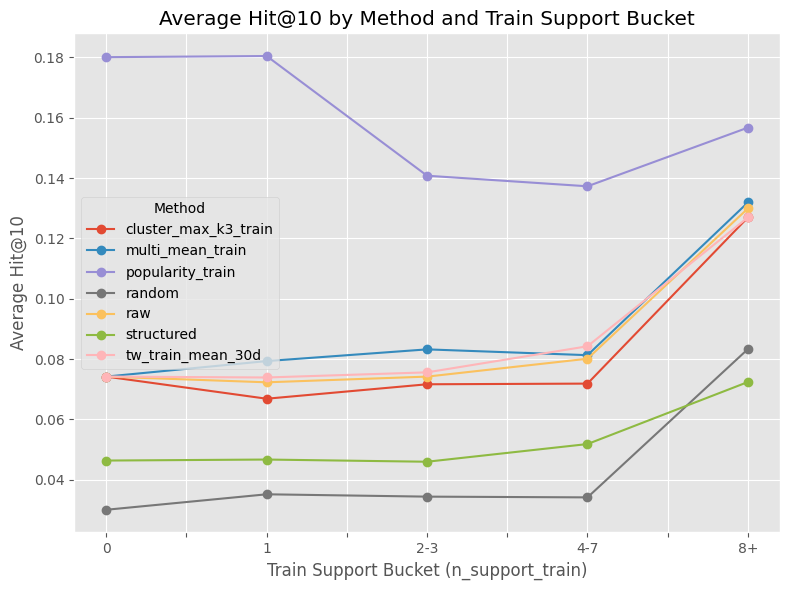

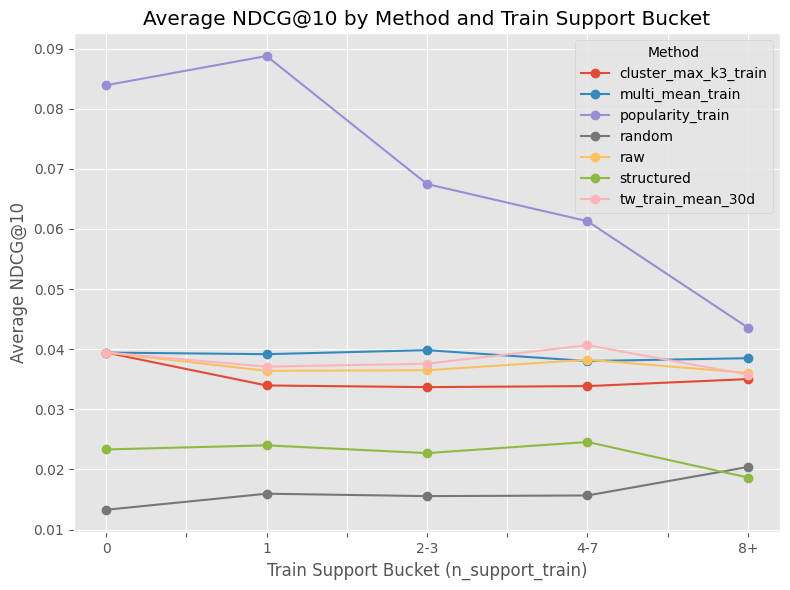

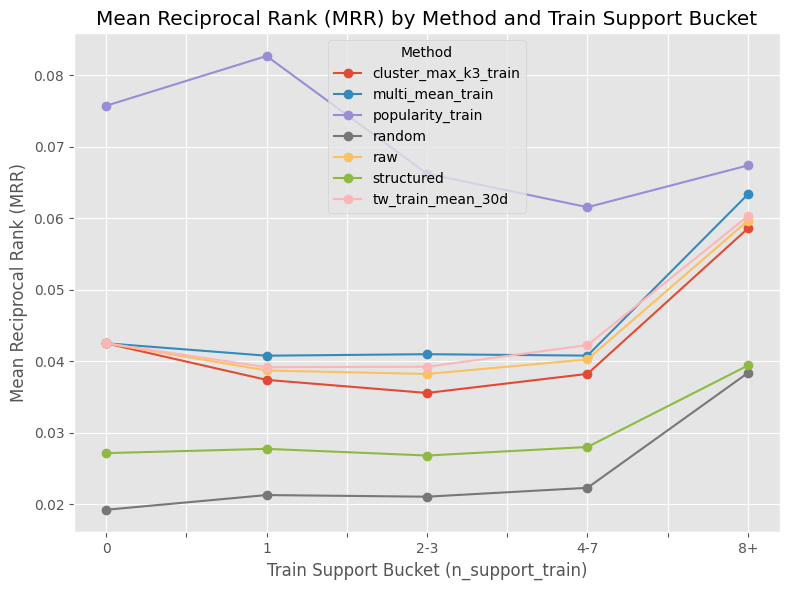

In [36]:
# Plotting the average Hit@K=10, NDCG@K=10, and MRR per method and by n_support_train bucket

import matplotlib.pyplot as plt

support_bins = [0, 1, 2, 4, 8, 1000]
support_labels = ["0", "1", "2-3", "4-7", "8+"]

df_ex_metrics["support_bucket"] = pd.cut(
    df_ex_metrics["n_support_train"],
    bins=support_bins,
    labels=support_labels,
    right=False,
    include_lowest=True,
)

# Aggregated by method and support_bucket for each metric
metrics_to_plot = {
    "Hit@K": "Average Hit@10",
    "NDCG@K": "Average NDCG@10",
    "MRR": "Mean Reciprocal Rank (MRR)"
}

for metric, ylabel in metrics_to_plot.items():
    avg_metric_by_method_and_support = (
        df_ex_metrics.groupby(["support_bucket", "method"])[metric]
        .mean()
        .reset_index()
        .pivot(index="support_bucket", columns="method", values=metric)
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    avg_metric_by_method_and_support.plot(marker='o', ax=ax)
    ax.set_title(f"{ylabel} by Method and Train Support Bucket")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Train Support Bucket (n_support_train)")
    ax.legend(title="Method")
    ax.grid(True, axis='y')
    plt.tight_layout()
    plt.show()

In [37]:
# --- 4.1 diagnostics: why train-support buckets behave differently ---

import numpy as np
import pandas as pd

if "df_ex_metrics" not in globals() or len(df_ex_metrics) == 0:
    raise RuntimeError("`df_ex_metrics` missing. Run Section 4.1 metric build first.")
if "examples" not in globals() or len(examples) == 0:
    raise RuntimeError("`examples` missing. Run Section 2 first.")
if "app_ids_X" not in globals() or "pop_row" not in globals():
    raise RuntimeError("`app_ids_X`/`pop_row` missing. Run setup + popularity baseline cells first.")

METRICS = ["Hit@K", "NDCG@K", "MRR"]
BASELINE_METHOD = "popularity_train"
TARGET_BUCKET = "8+"

def support_bucket(n: int) -> str:
    n = int(n)
    if n <= 0:
        return "0"
    if n == 1:
        return "1"
    if n <= 3:
        return "2-3"
    if n <= 7:
        return "4-7"
    return "8+"

bucket_order = ["0", "1", "2-3", "4-7", "8+"]

# 0) attach support bucket onto per-example metrics
diag = df_ex_metrics.copy()
diag["train_support_bucket"] = diag["n_support_train"].fillna(0).astype(int).map(support_bucket)
diag["train_support_bucket"] = pd.Categorical(
    diag["train_support_bucket"], categories=bucket_order, ordered=True
)

# 1) Bucket sizes (n_examples / n_users)
bucket_sizes = (
    diag.groupby("train_support_bucket", observed=True)
    .agg(
        n_rows=("ex_idx", "size"),
        n_examples=("ex_idx", "nunique"),
        n_users=("user_id", "nunique"),
    )
    .reset_index()
)
print("1) Bucket sizes")
display(bucket_sizes)


1) Bucket sizes


,train_support_bucket,n_rows,n_examples,n_users
0,0,21882,3126,3016
1,1,21875,3125,3101
2,2-3,24808,3544,3501
3,4-7,11879,1697,1679
4,8+,7056,1008,979


In [38]:
# 2) n_eval_targets distribution across buckets (example-level)
ex_level = (
    diag[["ex_idx", "user_id", "n_eval_targets", "n_support_train", "train_support_bucket"]]
    .drop_duplicates("ex_idx")
    .copy()
)

targets_dist = (
    ex_level.groupby(["train_support_bucket", "n_eval_targets"], observed=True)
    .size()
    .rename("n_examples")
    .reset_index()
    .sort_values(["train_support_bucket", "n_eval_targets"])
    .reset_index(drop=True)
)
print("2a) n_eval_targets distribution by support bucket")
display(targets_dist)

targets_summary = (
    ex_level.groupby("train_support_bucket", observed=True)
    .agg(
        n_examples=("ex_idx", "nunique"),
        avg_n_eval_targets=("n_eval_targets", "mean"),
        p50_n_eval_targets=("n_eval_targets", "median"),
        p90_n_eval_targets=("n_eval_targets", lambda s: float(np.percentile(s, 90))),
    )
    .reset_index()
)
print("2b) n_eval_targets summary by support bucket")
display(targets_summary)

2a) n_eval_targets distribution by support bucket


,train_support_bucket,n_eval_targets,n_examples
0,0,1,3126
1,1,1,3125
2,2-3,1,3539
3,2-3,2,5
4,4-7,1,1601
5,4-7,2,90
6,4-7,3,5
7,4-7,4,1
8,8+,1,330
9,8+,2,350


2b) n_eval_targets summary by support bucket


,train_support_bucket,n_examples,avg_n_eval_targets,p50_n_eval_targets,p90_n_eval_targets
0,0,3126,1.000000,1.0,1.0
1,1,3125,1.000000,1.0,1.0
2,2-3,3544,1.001411,1.0,1.0
3,4-7,1697,1.060695,1.0,1.0
4,8+,1008,2.336310,2.0,4.0


In [39]:
# 3) Head-vs-tail positives by bucket (popularity of true positives)
# pop_row is train positive count aligned to app_ids_X
app_pop = {int(a): float(c) for a, c in zip(app_ids_X, pop_row)}

pos_pop_rows = []
for ex_idx, ex in enumerate(examples):
    pos = [int(a) for a in ex.get("positives", [])]
    if not pos:
        continue
    vals = [app_pop.get(a, 0.0) for a in pos]
    n_sup = int(ex_level.loc[ex_level["ex_idx"] == ex_idx, "n_support_train"].iloc[0]) if (ex_level["ex_idx"] == ex_idx).any() else 0
    pos_pop_rows.append(
        {
            "ex_idx": ex_idx,
            "n_support_train": n_sup,
            "train_support_bucket": support_bucket(n_sup),
            "pos_pop_mean": float(np.mean(vals)),
            "pos_pop_median": float(np.median(vals)),
            "pos_pop_p90": float(np.percentile(vals, 90)),
            "n_eval_targets": len(pos),
        }
    )

df_pos_pop = pd.DataFrame(pos_pop_rows)
if len(df_pos_pop) > 0:
    df_pos_pop["train_support_bucket"] = pd.Categorical(
        df_pos_pop["train_support_bucket"], categories=bucket_order, ordered=True
    )
    head_tail = (
        df_pos_pop.groupby("train_support_bucket", observed=True)
        .agg(
            n_examples=("ex_idx", "nunique"),
            avg_pos_pop_mean=("pos_pop_mean", "mean"),
            med_pos_pop_median=("pos_pop_median", "median"),
            avg_pos_pop_p90=("pos_pop_p90", "mean"),
        )
        .reset_index()
    )
    print("3) Positive-target popularity by support bucket (head-vs-tail diagnostic)")
    display(head_tail)
else:
    print("3) No positive-target popularity rows available.")

3) Positive-target popularity by support bucket (head-vs-tail diagnostic)


,train_support_bucket,n_examples,avg_pos_pop_mean,med_pos_pop_median,avg_pos_pop_p90
0,0,3126,50934.046065,29388.0,50934.046065
1,1,3125,52165.914880,29727.0,52165.914880
2,2-3,3544,44508.034142,22870.0,44527.829853
3,4-7,1697,41370.652180,21463.0,42424.432292
4,8+,1008,32037.124270,17937.0,44490.594345


In [40]:
# 4) Method delta vs popularity by bucket
bucket_method = (
    diag.groupby(["train_support_bucket", "method"], observed=True)[METRICS]
    .mean()
    .reset_index()
)

pop_ref = (
    bucket_method[bucket_method["method"] == BASELINE_METHOD][["train_support_bucket"] + METRICS]
    .rename(columns={m: f"{m}_pop_ref" for m in METRICS})
)

delta_vs_pop = bucket_method.merge(pop_ref, on="train_support_bucket", how="left")
for m in METRICS:
    delta_vs_pop[f"{m}_delta_vs_pop"] = delta_vs_pop[m] - delta_vs_pop[f"{m}_pop_ref"]

print("4) Metric deltas vs popularity by bucket")
display(
    delta_vs_pop[
        ["train_support_bucket", "method"] + [f"{m}_delta_vs_pop" for m in METRICS]
    ].sort_values(["train_support_bucket", "method"]).reset_index(drop=True)
)

4) Metric deltas vs popularity by bucket


,train_support_bucket,method,Hit@K_delta_vs_pop,NDCG@K_delta_vs_pop,MRR_delta_vs_pop
0,0,cluster_max_k3_train,-0.105886,-0.044472,-0.033255
1,0,multi_mean_train,-0.105886,-0.044472,-0.033255
2,0,popularity_train,0.000000,0.000000,0.000000
3,0,random,-0.150032,-0.070619,-0.056561
4,0,raw,-0.105886,-0.044472,-0.033255
5,0,structured,-0.133717,-0.060586,-0.048632
6,0,tw_train_mean_30d,-0.105886,-0.044472,-0.033255
7,1,cluster_max_k3_train,-0.113600,-0.054798,-0.045336
8,1,multi_mean_train,-0.101120,-0.049594,-0.041953
9,1,popularity_train,0.000000,0.000000,0.000000


In [41]:
# 5) Per-user variance in 8+ bucket (broad lift vs few heavy winners)
diag_8p = diag[diag["train_support_bucket"] == TARGET_BUCKET].copy()
if len(diag_8p) == 0:
    print(f"5) No rows in bucket {TARGET_BUCKET}.")
else:
    user_method = (
        diag_8p.groupby(["method", "user_id"], observed=True)[METRICS]
        .mean()
        .reset_index()
    )
    user_var = (
        user_method.groupby("method", observed=True)
        .agg(
            n_users=("user_id", "nunique"),
            hit_mean=("Hit@K", "mean"),
            hit_std=("Hit@K", "std"),
            ndcg_mean=("NDCG@K", "mean"),
            ndcg_std=("NDCG@K", "std"),
            mrr_mean=("MRR", "mean"),
            mrr_std=("MRR", "std"),
        )
        .reset_index()
        .sort_values("ndcg_mean", ascending=False)
        .reset_index(drop=True)
    )
    print(f"5) Per-user variance in {TARGET_BUCKET} bucket")
    display(user_var)

    # Optional: simple concentration check (top 10% users by NDCG contribution)
    conc_rows = []
    for method, g in user_method.groupby("method", observed=True):
        vals = g["NDCG@K"].to_numpy(dtype=float)
        if len(vals) == 0:
            continue
        cutoff = max(1, int(np.ceil(0.10 * len(vals))))
        top_share = float(np.sort(vals)[-cutoff:].sum() / (vals.sum() + 1e-12))
        conc_rows.append({"method": method, "top10pct_user_share_of_ndcg": top_share})
    conc = pd.DataFrame(conc_rows).sort_values("top10pct_user_share_of_ndcg", ascending=False)
    print(f"5b) Concentration check in {TARGET_BUCKET} (higher = fewer users drive gains)")
    display(conc.reset_index(drop=True))

5) Per-user variance in 8+ bucket


,method,n_users,hit_mean,hit_std,ndcg_mean,ndcg_std,mrr_mean,mrr_std
0,popularity_train,979,0.157814,0.363700,0.043787,0.119717,0.067346,0.142917
1,multi_mean_train,979,0.129724,0.334647,0.038467,0.117580,0.062647,0.143702
2,raw,979,0.127681,0.330055,0.035892,0.111417,0.058928,0.141068
3,tw_train_mean_30d,979,0.125128,0.327539,0.035711,0.112269,0.059826,0.144712
4,cluster_max_k3_train,979,0.126149,0.331031,0.034942,0.107344,0.057756,0.140139
5,random,979,0.080695,0.268726,0.019936,0.080113,0.037149,0.090451
6,structured,979,0.069969,0.250678,0.018448,0.080834,0.038677,0.110319


5b) Concentration check in 8+ (higher = fewer users drive gains)


,method,top10pct_user_share_of_ndcg
0,random,1.000000
1,structured,1.000000
2,tw_train_mean_30d,0.912622
3,cluster_max_k3_train,0.905998
4,raw,0.903761
5,multi_mean_train,0.891661
6,popularity_train,0.802063


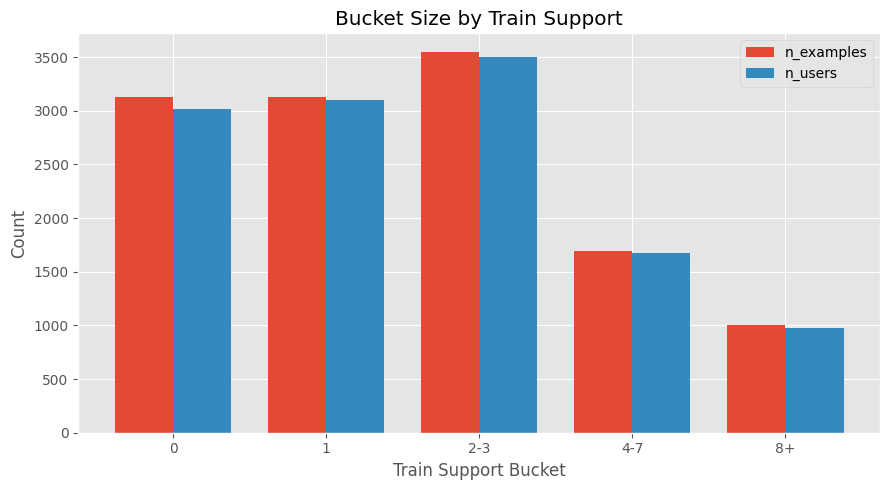

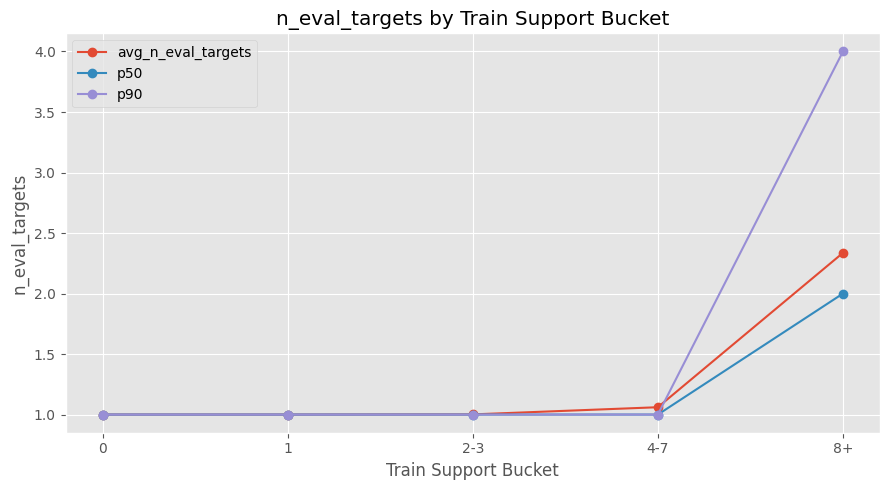

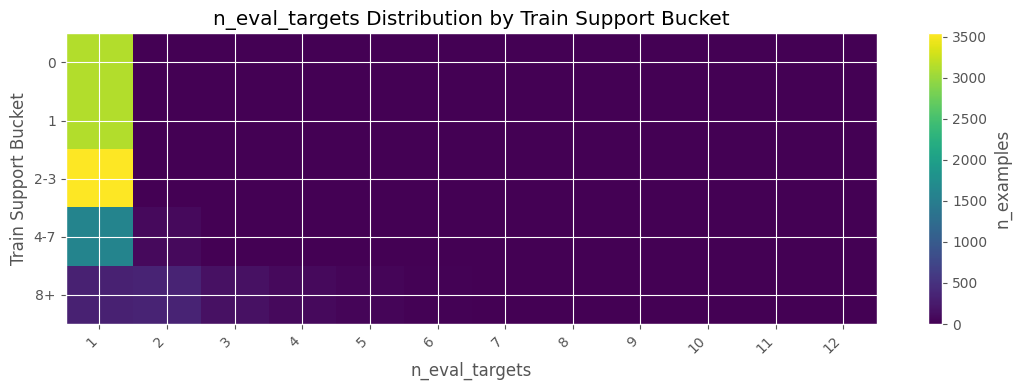

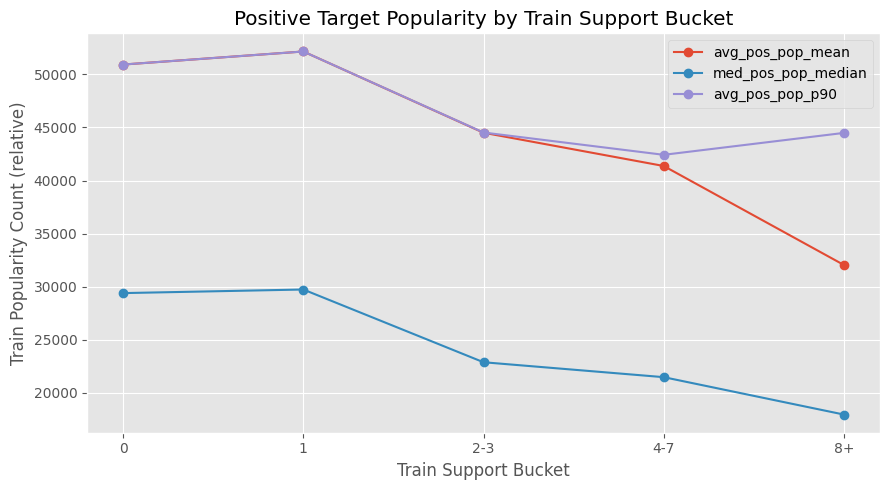

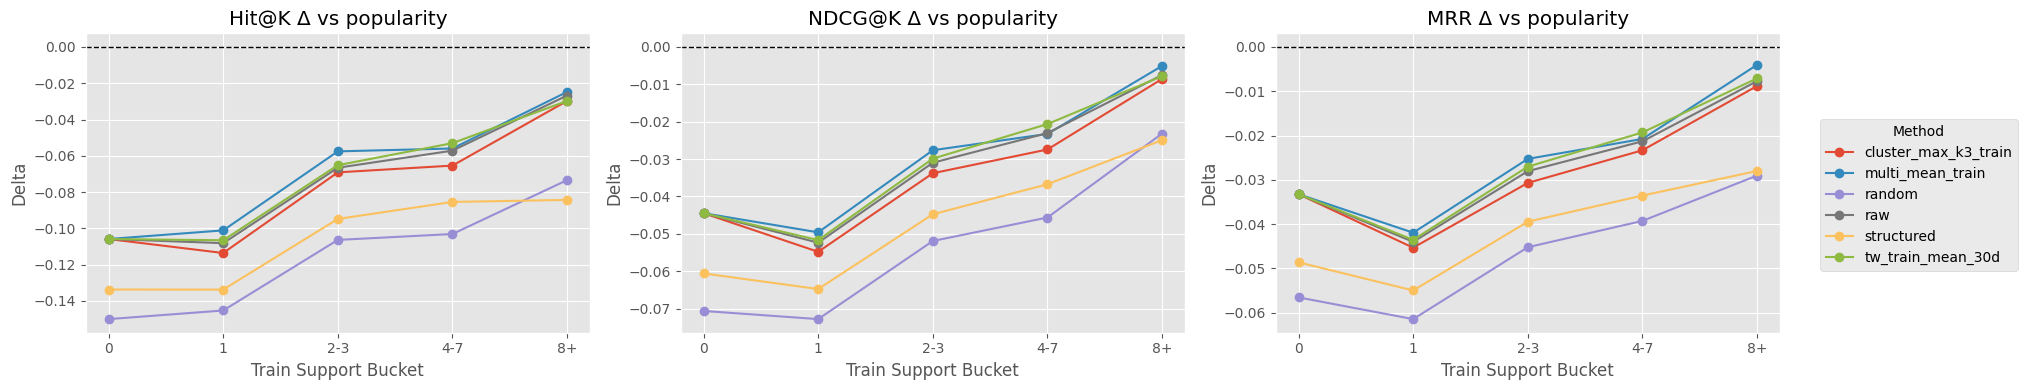

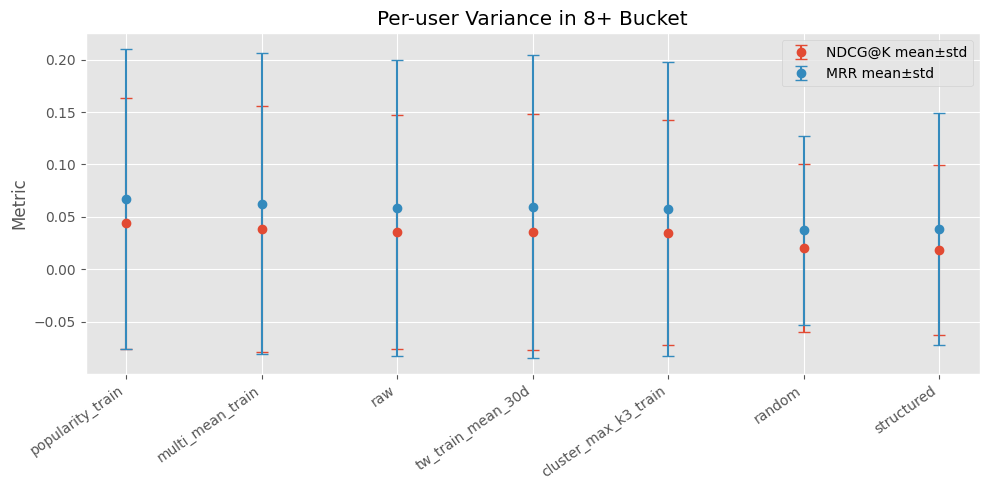

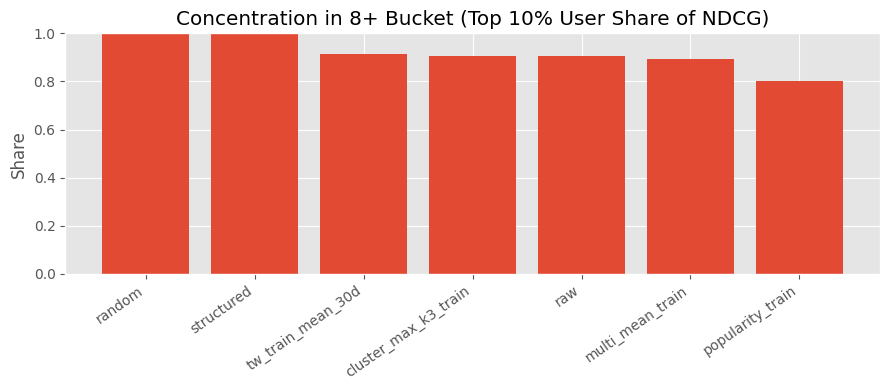

In [42]:
# --- Optional plots for the 4.1 diagnostics ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# expects these DataFrames from the diagnostic cell:
# bucket_sizes, targets_summary, targets_dist, head_tail, delta_vs_pop, user_var, conc

plt.style.use("ggplot")
bucket_order = ["0", "1", "2-3", "4-7", "8+"]

def _ordered(df, col="train_support_bucket"):
    out = df.copy()
    out[col] = pd.Categorical(out[col], categories=bucket_order, ordered=True)
    return out.sort_values(col)

# 1) Bucket sizes
if "bucket_sizes" in globals() and len(bucket_sizes) > 0:
    b = _ordered(bucket_sizes)
    x = np.arange(len(b))
    w = 0.38

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - w/2, b["n_examples"], width=w, label="n_examples")
    ax.bar(x + w/2, b["n_users"], width=w, label="n_users")
    ax.set_xticks(x)
    ax.set_xticklabels(b["train_support_bucket"].astype(str))
    ax.set_title("Bucket Size by Train Support")
    ax.set_xlabel("Train Support Bucket")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 2) n_eval_targets summary by bucket
if "targets_summary" in globals() and len(targets_summary) > 0:
    t = _ordered(targets_summary)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(t["train_support_bucket"].astype(str), t["avg_n_eval_targets"], marker="o", label="avg_n_eval_targets")
    ax.plot(t["train_support_bucket"].astype(str), t["p50_n_eval_targets"], marker="o", label="p50")
    ax.plot(t["train_support_bucket"].astype(str), t["p90_n_eval_targets"], marker="o", label="p90")
    ax.set_title("n_eval_targets by Train Support Bucket")
    ax.set_xlabel("Train Support Bucket")
    ax.set_ylabel("n_eval_targets")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 2b) distribution heatmap-like pivot
if "targets_dist" in globals() and len(targets_dist) > 0:
    td = _ordered(targets_dist)
    piv = td.pivot_table(
        index="train_support_bucket",
        columns="n_eval_targets",
        values="n_examples",
        aggfunc="sum",
        fill_value=0,
    )
    fig, ax = plt.subplots(figsize=(11, 4))
    im = ax.imshow(piv.values, aspect="auto")
    ax.set_yticks(np.arange(len(piv.index)))
    ax.set_yticklabels([str(x) for x in piv.index])
    ax.set_xticks(np.arange(len(piv.columns)))
    ax.set_xticklabels([str(x) for x in piv.columns], rotation=45, ha="right")
    ax.set_title("n_eval_targets Distribution by Train Support Bucket")
    ax.set_xlabel("n_eval_targets")
    ax.set_ylabel("Train Support Bucket")
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("n_examples")
    plt.tight_layout()
    plt.show()

# 3) Positive-target popularity diagnostics
if "head_tail" in globals() and len(head_tail) > 0:
    h = _ordered(head_tail)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(h["train_support_bucket"].astype(str), h["avg_pos_pop_mean"], marker="o", label="avg_pos_pop_mean")
    ax.plot(h["train_support_bucket"].astype(str), h["med_pos_pop_median"], marker="o", label="med_pos_pop_median")
    ax.plot(h["train_support_bucket"].astype(str), h["avg_pos_pop_p90"], marker="o", label="avg_pos_pop_p90")
    ax.set_title("Positive Target Popularity by Train Support Bucket")
    ax.set_xlabel("Train Support Bucket")
    ax.set_ylabel("Train Popularity Count (relative)")
    ax.legend()
    plt.tight_layout()
    plt.show()

# 4) Delta vs popularity by bucket (small multiples)
if "delta_vs_pop" in globals() and len(delta_vs_pop) > 0:
    d = _ordered(delta_vs_pop)
    methods = [m for m in sorted(d["method"].unique()) if m != "popularity_train"]
    metrics = ["Hit@K_delta_vs_pop", "NDCG@K_delta_vs_pop", "MRR_delta_vs_pop"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)
    for ax, metric in zip(axes, metrics):
        for m in methods:
            dm = d[d["method"] == m]
            ax.plot(
                dm["train_support_bucket"].astype(str),
                dm[metric],
                marker="o",
                label=m,
            )
        ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
        ax.set_title(metric.replace("_delta_vs_pop", " Δ vs popularity"))
        ax.set_xlabel("Train Support Bucket")
        ax.set_ylabel("Delta")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), title="Method")
    plt.tight_layout()
    plt.show()

# 5) Per-user variance in 8+ bucket
if "user_var" in globals() and len(user_var) > 0:
    uv = user_var.sort_values("ndcg_mean", ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(uv))
    ax.errorbar(x, uv["ndcg_mean"], yerr=uv["ndcg_std"], fmt="o", capsize=4, label="NDCG@K mean±std")
    ax.errorbar(x, uv["mrr_mean"], yerr=uv["mrr_std"], fmt="o", capsize=4, label="MRR mean±std")
    ax.set_xticks(x)
    ax.set_xticklabels(uv["method"], rotation=35, ha="right")
    ax.set_title("Per-user Variance in 8+ Bucket")
    ax.set_ylabel("Metric")
    ax.legend()
    plt.tight_layout()
    plt.show()
if "conc" in globals() and len(conc) > 0:
    c = conc.sort_values("top10pct_user_share_of_ndcg", ascending=False).reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(c["method"], c["top10pct_user_share_of_ndcg"])
    ax.set_title("Concentration in 8+ Bucket (Top 10% User Share of NDCG)")
    ax.set_ylabel("Share")
    ax.set_ylim(0, 1)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## 4.2 By item popularity decile of positives

`pos_pop_decile` is based on each example's mean train popularity across that example's positive app_ids.

Decile direction (important): `D1` is the least-popular decile and `D10` is the most-popular decile (from `pd.qcut` in ascending order).

Interpretation note: in the current `NDCG@K delta vs popularity` view, non-pop methods are slightly positive across `D1-D8`, then turn negative in `D9-D10` (especially `D10`). So popularity baseline has its strongest edge on the highest-popularity target deciles.

In [11]:
# Per-example positive-set popularity features
app_pop = {int(a): float(c) for a, c in zip(app_ids_X, pop_row)}

pos_pop_rows = []
for ex_idx, ex in enumerate(examples):
    vals = [app_pop.get(int(a), 0.0) for a in ex["positives"]]
    pos_pop_rows.append(
        {
            "ex_idx": ex_idx,
            "pos_pop_mean": float(np.mean(vals)) if len(vals) else np.nan,
            "pos_pop_median": float(np.median(vals)) if len(vals) else np.nan,
        }
    )

df_ex_pop = pd.DataFrame(pos_pop_rows)

valid = df_ex_pop["pos_pop_mean"].notna()
# Use qcut for deciles; duplicates='drop' avoids failures when many ties exist.
df_ex_pop.loc[valid, "pos_pop_decile"] = pd.qcut(
    df_ex_pop.loc[valid, "pos_pop_mean"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
    duplicates="drop",
)
df_ex_pop["pos_pop_decile"] = df_ex_pop["pos_pop_decile"].astype("string")

# Aggregate metrics by (decile, method)
df_seg_pop = df_ex_metrics.merge(df_ex_pop, on="ex_idx", how="left")

pop_table = (
    df_seg_pop.dropna(subset=["pos_pop_decile"])
    .groupby(["pos_pop_decile", "method"], observed=True)[METRIC_COLS]
    .mean()
    .reset_index()
    .sort_values(["pos_pop_decile", "method"])
)

display(pop_table)

# Delta vs popularity baseline within each decile
pop_ref = pop_table[pop_table["method"] == "popularity_train"][["pos_pop_decile"] + METRIC_COLS].rename(
    columns={m: f"{m}_pop_ref" for m in METRIC_COLS}
)
pop_delta = pop_table.merge(pop_ref, on="pos_pop_decile", how="left")
for m in METRIC_COLS:
    pop_delta[f"{m}_delta_vs_pop"] = pop_delta[m] - pop_delta[f"{m}_pop_ref"]

display(
    pop_delta[pop_delta["method"] != "popularity_train"][
        ["pos_pop_decile", "method"] + [f"{m}_delta_vs_pop" for m in METRIC_COLS]
    ].sort_values(["pos_pop_decile", "method"])
)

,pos_pop_decile,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,D1,cluster_max_k3_train,0.095019,0.093103,0.029082,0.044002,0.044243
1,D1,multi_mean_train,0.101149,0.100383,0.033146,0.048830,0.048815
2,D1,popularity_train,0.000000,0.000000,0.000000,0.000000,0.005221
3,D1,raw,0.085824,0.083008,0.028390,0.041350,0.042811
4,D1,structured,0.095019,0.093582,0.030047,0.044755,0.044222
5,D1,tw_train_mean_30d,0.089655,0.086839,0.031045,0.044262,0.045355
6,D10,cluster_max_k3_train,0.049011,0.048581,0.013217,0.021294,0.028535
7,D10,multi_mean_train,0.070507,0.069647,0.018925,0.030529,0.035396
8,D10,popularity_train,1.000000,0.997420,0.438432,0.574014,0.441373
9,D10,raw,0.061909,0.060619,0.015812,0.026265,0.031192


,pos_pop_decile,method,Hit@K_delta_vs_pop,Recall@K_delta_vs_pop,MAP@K_delta_vs_pop,NDCG@K_delta_vs_pop,MRR_delta_vs_pop
0,D1,cluster_max_k3_train,0.095019,0.093103,0.029082,0.044002,0.039022
1,D1,multi_mean_train,0.101149,0.100383,0.033146,0.048830,0.043594
3,D1,raw,0.085824,0.083008,0.028390,0.041350,0.037590
4,D1,structured,0.095019,0.093582,0.030047,0.044755,0.039001
5,D1,tw_train_mean_30d,0.089655,0.086839,0.031045,0.044262,0.040134
6,D10,cluster_max_k3_train,-0.950989,-0.948839,-0.425215,-0.552720,-0.412838
7,D10,multi_mean_train,-0.929493,-0.927773,-0.419508,-0.543485,-0.405977
9,D10,raw,-0.938091,-0.936801,-0.422620,-0.547749,-0.410181
10,D10,structured,-0.992261,-0.989682,-0.436087,-0.570409,-0.432537
11,D10,tw_train_mean_30d,-0.933792,-0.932072,-0.421736,-0.546001,-0.409201


In [45]:
pop_delta.head(5)

,pos_pop_decile,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR,Hit@K_pop_ref,Recall@K_pop_ref,MAP@K_pop_ref,NDCG@K_pop_ref,MRR_pop_ref,Hit@K_delta_vs_pop,Recall@K_delta_vs_pop,MAP@K_delta_vs_pop,NDCG@K_delta_vs_pop,MRR_delta_vs_pop
0,D1,cluster_max_k3_train,0.095019,0.093103,0.029082,0.044002,0.044243,0.0,0.0,0.0,0.0,0.005221,0.095019,0.093103,0.029082,0.044002,0.039022
1,D1,multi_mean_train,0.101149,0.100383,0.033146,0.048830,0.048815,0.0,0.0,0.0,0.0,0.005221,0.101149,0.100383,0.033146,0.048830,0.043594
2,D1,popularity_train,0.000000,0.000000,0.000000,0.000000,0.005221,0.0,0.0,0.0,0.0,0.005221,0.000000,0.000000,0.000000,0.000000,0.000000
3,D1,raw,0.085824,0.083008,0.028390,0.041350,0.042811,0.0,0.0,0.0,0.0,0.005221,0.085824,0.083008,0.028390,0.041350,0.037590
4,D1,structured,0.095019,0.093582,0.030047,0.044755,0.044222,0.0,0.0,0.0,0.0,0.005221,0.095019,0.093582,0.030047,0.044755,0.039001


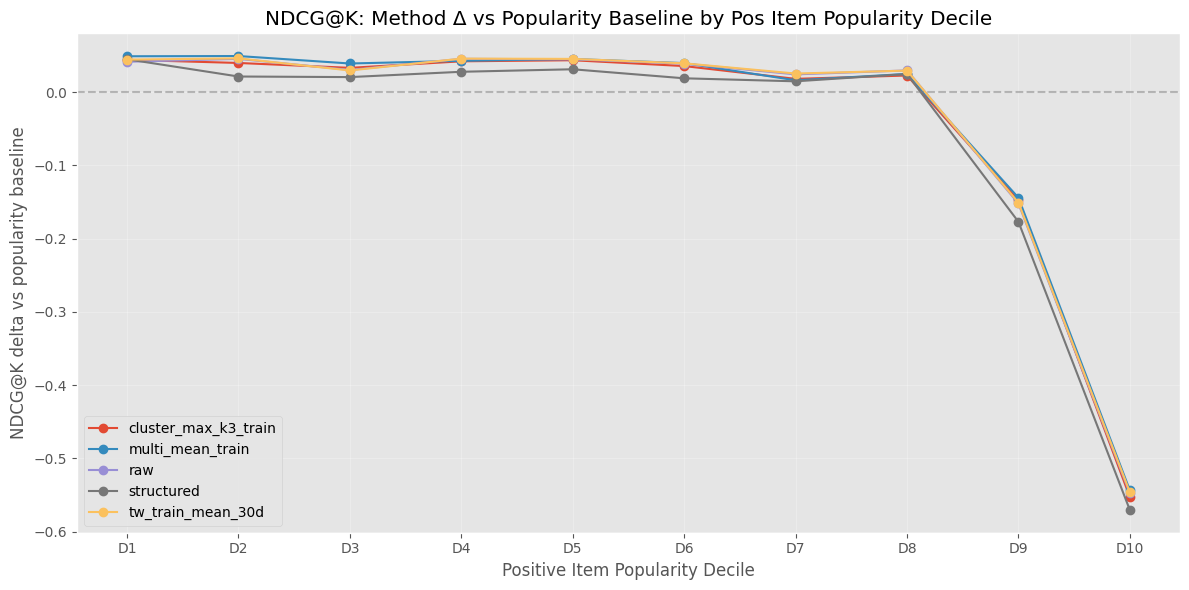

In [44]:
import matplotlib.pyplot as plt

# Plot NDCG delta vs popularity baseline for each method (excluding "popularity_train") across pos_pop_deciles
plt.figure(figsize=(12, 6))

# Only plot methods other than the popularity baseline itself
methods = [m for m in pop_delta["method"].unique() if m != "popularity_train"]
deciles = pop_delta["pos_pop_decile"].unique()
# Ensure decile order by sorting, with string-to-int except (e.g. D1, D2, ...)
deciles_sorted = sorted([d for d in deciles if d.startswith("D")], key=lambda x: int(x[1:]))

for method in methods:
    df_plot = pop_delta[pop_delta["method"] == method]
    # Filter by deciles present in this group, in deciles_sorted order
    ndcg_delta_vals = []
    deciles_exist = []
    for dec in deciles_sorted:
        v = df_plot[df_plot["pos_pop_decile"] == dec]
        if not v.empty:
            # Use the _delta_vs_pop column to plot relative improvements/shifts
            ndcg_delta_vals.append(v["NDCG@K_delta_vs_pop"].values[0])
            deciles_exist.append(dec)
    plt.plot(deciles_exist, ndcg_delta_vals, marker='o', label=method)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel("Positive Item Popularity Decile")
plt.ylabel("NDCG@K delta vs popularity baseline")
plt.title("NDCG@K: Method Δ vs Popularity Baseline by Pos Item Popularity Decile")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Explanation:
# - We do NOT plot the "popularity_train" lines, since by construction its delta is always zero.
# - This avoids confusion: by using only the _delta_vs_pop columns and skipping the popularity baseline,
#   the y-axis zero line is always the baseline (popularity) itself, and plotted values are improvements or losses vs that baseline.

## 4.3 By user-history complexity

`complexity_score` is a standardized blend of per-example difficulty/context signals:

- `z(log1p(n_eval_targets))`
- `z(log1p(n_support_train))`
- `z(log1p(n_unique_train_apps))`
- plus `z(genre_diversity)` when train `genres` is available

Higher `complexity_score` means an example has broader/more varied user-history context (and often more eval targets). Lower means sparse/narrow context. After scoring, examples are binned into tertiles (`low`, `mid`, `high`) for robust segment comparison.

Interpretation note: method performance can differ meaningfully by complexity bucket (`method x cohort` interaction). Treat this section as a guardrail view, not just an appendix: a method that wins on overall average can still regress specific user cohorts.

In [12]:
# Base complexity features per example
base = (
    df_ex_metrics[["ex_idx", "user_id", "n_eval_targets", "n_support_train", "n_unique_train_apps"]]
    .drop_duplicates("ex_idx")
    .copy()
)

# Optional: liked-genre diversity from train data if a genres column exists
liked_genre_counts = None
try:
    train_cols = [USER_COL, "recommended", "genres"]
    _df_train_g = pd.read_parquet(TRAIN_PARQUET, columns=train_cols)
    _df_train_g = _df_train_g[_df_train_g["recommended"] == 1].copy()

    def _split_genres(x):
        if pd.isna(x):
            return []
        s = str(x)
        parts = [p.strip() for p in s.replace("|", ",").split(",")]
        return [p for p in parts if p]

    _df_train_g["genre_list"] = _df_train_g["genres"].map(_split_genres)
    liked_genre_counts = (
        _df_train_g.explode("genre_list")
        .dropna(subset=["genre_list"])
        .groupby(USER_COL)["genre_list"]
        .nunique()
        .rename("n_liked_genres_train")
        .reset_index()
        .rename(columns={USER_COL: "user_id"})
    )
except Exception as e:
    print("Genre diversity feature unavailable:", repr(e))

if liked_genre_counts is not None and len(liked_genre_counts):
    base = base.merge(liked_genre_counts, on="user_id", how="left")
else:
    base["n_liked_genres_train"] = np.nan


def _z(v: pd.Series) -> pd.Series:
    v = pd.Series(v, dtype="float64")
    if v.isna().all() or float(v.std(ddof=0)) == 0.0:
        return pd.Series(np.zeros(len(v)), index=v.index)
    return (v - v.mean()) / v.std(ddof=0)


score_parts = [
    _z(np.log1p(base["n_eval_targets"])),
    _z(np.log1p(base["n_support_train"])),
    _z(np.log1p(base["n_unique_train_apps"])),
]
if base["n_liked_genres_train"].notna().any():
    score_parts.append(_z(np.log1p(base["n_liked_genres_train"].fillna(0))))

base["complexity_score"] = np.vstack(score_parts).mean(axis=0)

# Tertiles are more stable than deciles for small sample sizes.
# Use integer labels first so qcut can drop duplicate bins safely.
base["complexity_bucket"] = pd.Series(pd.NA, index=base.index, dtype="string")
_n_unique_scores = int(base["complexity_score"].nunique(dropna=True))
if _n_unique_scores <= 1:
    # Degenerate case: all examples have effectively the same complexity.
    base.loc[base["complexity_score"].notna(), "complexity_bucket"] = "mid"
else:
    _codes = pd.qcut(
        base["complexity_score"],
        q=3,
        labels=False,
        duplicates="drop",
    )
    _bucket_names = np.array(["low", "mid", "high"], dtype=object)
    _valid_codes = _codes.notna()
    base.loc[_valid_codes, "complexity_bucket"] = _bucket_names[_codes[_valid_codes].astype(int)].astype(str)

df_seg_complex = df_ex_metrics.merge(
    base[["ex_idx", "complexity_score", "complexity_bucket"]],
    on="ex_idx",
    how="left",
)

complex_table = (
    df_seg_complex.dropna(subset=["complexity_bucket"])
    .groupby(["complexity_bucket", "method"], observed=True)[METRIC_COLS]
    .mean()
    .reset_index()
    .sort_values(["complexity_bucket", "method"])
)

display(complex_table)

# Delta vs popularity baseline within each complexity bucket
c_ref = complex_table[complex_table["method"] == "popularity_train"][["complexity_bucket"] + METRIC_COLS].rename(
    columns={m: f"{m}_pop_ref" for m in METRIC_COLS}
)
c_delta = complex_table.merge(c_ref, on="complexity_bucket", how="left")
for m in METRIC_COLS:
    c_delta[f"{m}_delta_vs_pop"] = c_delta[m] - c_delta[f"{m}_pop_ref"]

display(
    c_delta[c_delta["method"] != "popularity_train"][
        ["complexity_bucket", "method"] + [f"{m}_delta_vs_pop" for m in METRIC_COLS]
    ].sort_values(["complexity_bucket", "method"])
)

print("\nCounts by complexity bucket:")
display(base["complexity_bucket"].value_counts(dropna=False).sort_index())

Genre diversity feature unavailable: ArrowInvalid('No match for FieldRef.Name(genres) in review_id: int64\napp_id: int64\napp_name: large_string\nauthor.steamid: int64\nlanguage: large_string\nreview: large_string\nrecommended: int64\nvotes_helpful: int64\nauthor.num_games_owned: int64\nauthor.num_reviews: int64\nauthor.playtime_last_two_weeks: double\nauthor.playtime_at_review: double\nsteam_purchase: int64\nreceived_for_free: int64\nwritten_during_early_access: int64\ntimestamp_created: int64\nauthor.last_played: double\nis_helpful: int64\nreview_word_count: int64\nreview_length_chars: int64\nreview_age_seconds: double\n_norm_votes_helpful: double\n_norm_author__playtime_last_two_weeks: double\n_norm_author__playtime_at_review: double\n_norm_author__num_games_owned: double\n_norm_author__num_reviews: double\n_norm_review_word_count: double\n__fragment_index: int32\n__batch_index: int32\n__last_in_fragment: bool\n__filename: string')


,complexity_bucket,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,high,cluster_max_k3_train,0.085064,0.067194,0.021102,0.033538,0.042037
1,high,multi_mean_train,0.093570,0.075948,0.023874,0.037640,0.045661
2,high,popularity_train,0.141356,0.120182,0.035603,0.056926,0.062691
3,high,raw,0.091318,0.072253,0.024107,0.037146,0.044369
4,high,structured,0.052539,0.040791,0.013635,0.021011,0.029398
5,high,tw_train_mean_30d,0.092820,0.073892,0.025225,0.038398,0.045639
6,low,cluster_max_k3_train,0.070549,0.070549,0.026629,0.036695,0.039939
7,low,multi_mean_train,0.076788,0.076788,0.028105,0.039297,0.041630
8,low,popularity_train,0.180291,0.180291,0.058130,0.086329,0.079233
9,low,raw,0.073268,0.073268,0.027325,0.037913,0.040597


,complexity_bucket,method,Hit@K_delta_vs_pop,Recall@K_delta_vs_pop,MAP@K_delta_vs_pop,NDCG@K_delta_vs_pop,MRR_delta_vs_pop
0,high,cluster_max_k3_train,-0.056292,-0.052988,-0.014501,-0.023388,-0.020654
1,high,multi_mean_train,-0.047786,-0.044234,-0.011729,-0.019286,-0.017030
3,high,raw,-0.050038,-0.047930,-0.011496,-0.019780,-0.018322
4,high,structured,-0.088817,-0.079392,-0.021968,-0.035915,-0.033293
5,high,tw_train_mean_30d,-0.048536,-0.046291,-0.010378,-0.018528,-0.017052
6,low,cluster_max_k3_train,-0.109742,-0.109742,-0.031501,-0.049634,-0.039295
7,low,multi_mean_train,-0.103503,-0.103503,-0.030025,-0.047032,-0.037603
9,low,raw,-0.107023,-0.107023,-0.030805,-0.048417,-0.038636
10,low,structured,-0.133739,-0.133739,-0.041292,-0.062671,-0.051812
11,low,tw_train_mean_30d,-0.106223,-0.106223,-0.030595,-0.048073,-0.038410



Counts by complexity bucket:


complexity_bucket
high    3997
low     6251
mid     2252
Name: count, dtype: int64[pyarrow]

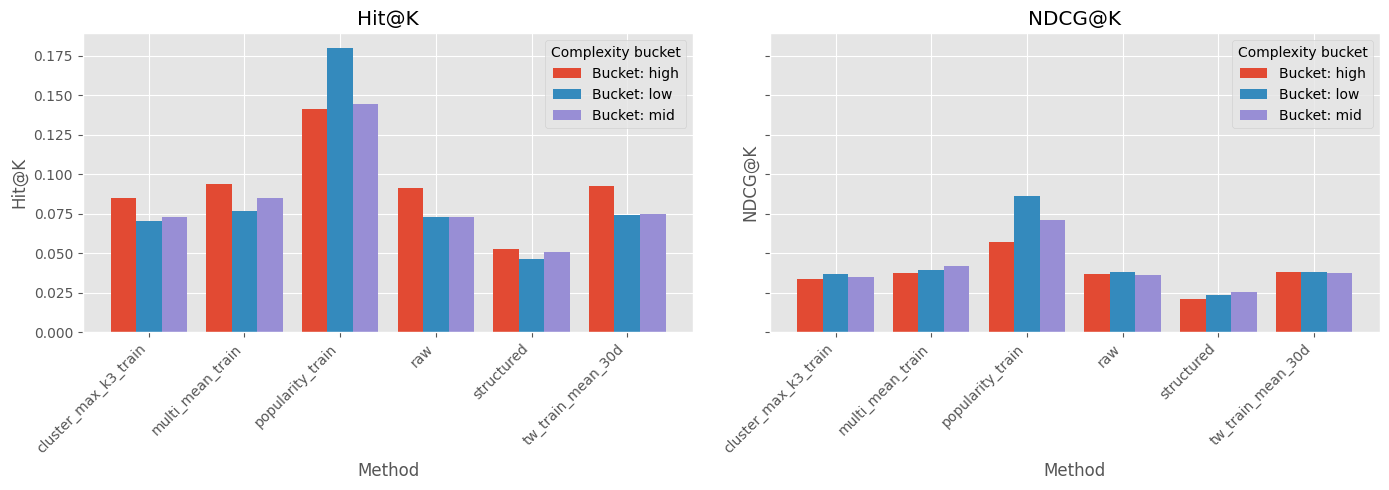

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Plot Hit@K and NDCG@K by method and complexity_bucket as bar graph

methods = c_delta["method"].unique()
buckets = c_delta["complexity_bucket"].unique()
x = np.arange(len(methods))  # label locations
width = 0.8 / len(buckets)   # width of the bars

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, metric in enumerate(["Hit@K", "NDCG@K"]):
    ax = axes[i]
    for j, bucket in enumerate(buckets):
        subset = c_delta[c_delta["complexity_bucket"] == bucket]
        # Align subset so its method order matches the overall methods order for reliable plotting
        subset = subset.set_index("method").reindex(methods)
        values = subset[metric].values
        ax.bar(x + j * width, values, width=width, label=f'Bucket: {bucket}')
    ax.set_title(metric)
    ax.set_xticks(x + width * (len(buckets) - 1) / 2)
    ax.set_xticklabels(methods, rotation=45, ha='right')
    ax.set_ylabel(metric)
    ax.set_xlabel('Method')
    ax.legend(title="Complexity bucket")

plt.tight_layout()
plt.show()

## 7) Two-panel decision (sparse-user aware)

Apply the policy from `docs/retrieval_metrics_guide.md`:

- **Panel 1 (primary):** `n_eval_targets >= 2` using `NDCG@10`.
- **Panel 2 (coverage):** `n_eval_targets == 1` using `Hit@10`.
- Tie-breaks: Panel 1 `NDCG@10` (primary) -> Panel 2 `Hit@10` if within delta `<= 0.01` -> Panel 1 `MAP@10` -> Panel 1 `MRR`.


In [13]:
# Two-panel scoreboards + automatic winner selection
TIE_DELTA = 0.01
PRIMARY_METRIC = "NDCG@K"
COVERAGE_METRIC = "Hit@K"

if "df_ex_metrics" not in globals() or len(df_ex_metrics) == 0:
    raise RuntimeError("`df_ex_metrics` is missing. Run Sections 2-6 first.")

if "examples" not in globals() or len(examples) == 0:
    raise RuntimeError("`examples` is missing. Run Section 2 first.")

# Per-example positive-count table (includes n_eval_targets==0 examples that are absent from df_ex_metrics).
ex_npos = pd.DataFrame(
    {
        "ex_idx": np.arange(len(examples), dtype=int),
        "n_eval_targets": [int(ex.get("n_eval_targets", 0)) for ex in examples],
    }
)

n_total = int(len(ex_npos))
n_multi_pos = int((ex_npos["n_eval_targets"] >= 2).sum())
n_single_pos = int((ex_npos["n_eval_targets"] == 1).sum())
n_zero_pos = int((ex_npos["n_eval_targets"] == 0).sum())
coverage_multi_pos = float(n_multi_pos / n_total) if n_total else np.nan

coverage_report = pd.DataFrame(
    [
        {
            "n_total": n_total,
            "n_multi_pos": n_multi_pos,
            "n_single_pos": n_single_pos,
            "n_zero_pos": n_zero_pos,
            "coverage_multi_pos": coverage_multi_pos,
        }
    ]
)

print("Coverage report:")
display(coverage_report)

# Merge n_eval_targets onto per-method metrics.
df_decision = df_ex_metrics.merge(
    ex_npos,
    on="ex_idx",
    how="left",
    validate="many_to_one",
    suffixes=("", "_from_examples"),
)

# If df_ex_metrics already had n_eval_targets, merge may suffix columns.
if "n_eval_targets" not in df_decision.columns:
    if "n_eval_targets_from_examples" in df_decision.columns:
        df_decision["n_eval_targets"] = df_decision["n_eval_targets_from_examples"]
    elif "n_eval_targets_x" in df_decision.columns:
        df_decision["n_eval_targets"] = df_decision["n_eval_targets_x"]
    elif "n_eval_targets_y" in df_decision.columns:
        df_decision["n_eval_targets"] = df_decision["n_eval_targets_y"]

if "n_eval_targets" not in df_decision.columns:
    raise RuntimeError(
        "Decision panel requires 'n_eval_targets' column after merge. "
        f"Available columns: {sorted(df_decision.columns.tolist())}"
    )

# Panel 1: n_eval_targets >= 2
panel1 = (
    df_decision[df_decision["n_eval_targets"] >= 2]
    .groupby("method", observed=True)[METRIC_COLS]
    .mean()
    .reset_index()
    .sort_values([PRIMARY_METRIC, "MAP@K", "MRR"], ascending=False)
    .reset_index(drop=True)
)

# Panel 2: n_eval_targets == 1
panel2 = (
    df_decision[df_decision["n_eval_targets"] == 1]
    .groupby("method", observed=True)[METRIC_COLS]
    .mean()
    .reset_index()
    .sort_values([COVERAGE_METRIC, "MRR"], ascending=False)
    .reset_index(drop=True)
)

print("Panel 1 (n_eval_targets >= 2) scoreboard:")
if panel1.empty:
    print("No multi-positive examples available.")
else:
    display(panel1)

print("Panel 2 (n_eval_targets == 1) scoreboard:")
if panel2.empty:
    print("No single-positive examples available.")
else:
    display(panel2)

# Winner selection per policy.
winner_notes = []
winner_method = None

if panel1.empty:
    winner_notes.append("No Panel 1 data; cannot run policy winner selection.")
else:
    p1 = panel1.copy()
    top_ndcg = float(p1[PRIMARY_METRIC].max())
    p1_close = p1[p1[PRIMARY_METRIC] >= (top_ndcg - TIE_DELTA)].copy()

    if len(p1_close) == 1:
        winner_method = str(p1_close.iloc[0]["method"])
        winner_notes.append(
            f"Single Panel 1 winner by {PRIMARY_METRIC}: {winner_method}"
        )
    else:
        winner_notes.append(
            f"Panel 1 tie set within delta <= {TIE_DELTA:.3f}: {len(p1_close)} methods"
        )

        if panel2.empty:
            p1_close = p1_close.sort_values(["MAP@K", "MRR"], ascending=False).reset_index(drop=True)
            winner_method = str(p1_close.iloc[0]["method"])
            winner_notes.append("Panel 2 unavailable; tie broken by Panel 1 MAP@K then MRR.")
        else:
            p2 = panel2[["method", COVERAGE_METRIC, "MRR"]].rename(
                columns={COVERAGE_METRIC: "Hit_panel2", "MRR": "MRR_panel2"}
            )
            merged = p1_close.merge(p2, on="method", how="left")
            merged["Hit_panel2"] = merged["Hit_panel2"].fillna(-np.inf)
            merged["MRR_panel2"] = merged["MRR_panel2"].fillna(-np.inf)
            merged = merged.sort_values(
                ["Hit_panel2", "MAP@K", "MRR", "MRR_panel2"],
                ascending=False,
            ).reset_index(drop=True)
            winner_method = str(merged.iloc[0]["method"])
            winner_notes.append("Tie broken by Panel 2 Hit@K, then Panel 1 MAP@K, then Panel 1 MRR.")

winner_report = pd.DataFrame(
    [
        {
            "winner_method": winner_method,
            "primary_metric": PRIMARY_METRIC,
            "coverage_metric": COVERAGE_METRIC,
            "tie_delta": TIE_DELTA,
            "notes": " | ".join(winner_notes) if winner_notes else "",
        }
    ]
)

print("Decision output:")
display(winner_report)


Coverage report:


,n_total,n_multi_pos,n_single_pos,n_zero_pos,coverage_multi_pos
0,12500,779,11721,0,0.06232


Panel 1 (n_eval_targets >= 2) scoreboard:


,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,popularity_train,0.187420,0.078779,0.024088,0.047196,0.081177
1,raw,0.161746,0.063921,0.023421,0.042631,0.074810
2,tw_train_mean_30d,0.159178,0.062060,0.022452,0.041396,0.074501
3,multi_mean_train,0.150193,0.059777,0.019913,0.038530,0.073079
4,cluster_max_k3_train,0.152760,0.061073,0.019636,0.038348,0.070077
5,structured,0.093710,0.033429,0.010341,0.021437,0.047160


Panel 2 (n_eval_targets == 1) scoreboard:


,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,popularity_train,0.159628,0.159628,0.050953,0.075923,0.071600
1,multi_mean_train,0.079259,0.079259,0.027330,0.039256,0.041084
2,tw_train_mean_30d,0.074908,0.074908,0.026878,0.037976,0.039980
3,raw,0.073543,0.073543,0.026108,0.037057,0.039187
4,cluster_max_k3_train,0.070472,0.070472,0.024569,0.035119,0.037961
5,structured,0.046242,0.046242,0.016342,0.023217,0.027028


Decision output:


,winner_method,primary_metric,coverage_metric,tie_delta,notes
0,popularity_train,NDCG@K,Hit@K,0.01,Panel 1 tie set within delta <= 0.010: 5 metho...


### Section 7 note: what `n_eval_targets` means

`n_eval_targets` is the number of **eval-split positives** for each example, not train positives.

For Task A, after choosing the query game, `n_eval_targets` counts how many **other liked apps in the eval split** remain as targets for that example.

So Panel 2 (`n_eval_targets == 1`) means "single eval target," but those examples can still have train support (`n_support_train > 0`).

In [14]:
# Panel 2 diagnostic: split by train-history support
if "df_decision" not in globals() or len(df_decision) == 0:
    raise RuntimeError("`df_decision` missing; run the Section 7 decision cell first.")

if "n_support_train" not in df_decision.columns:
    raise RuntimeError(
        "`n_support_train` missing in df_decision. Re-run per-example metrics build section first."
    )

p2 = df_decision[df_decision["n_eval_targets"] == 1].copy()
p2["support_bucket"] = np.where(p2["n_support_train"] > 0, "support_gt_0", "support_eq_0")

panel2_support = (
    p2.groupby(["support_bucket", "method"], observed=True)[METRIC_COLS]
    .mean()
    .reset_index()
    .sort_values(["support_bucket", "Hit@K", "MRR"], ascending=[True, False, False])
    .reset_index(drop=True)
)

panel2_support_counts = (
    p2.groupby("support_bucket", observed=True)
    .agg(n_examples=("ex_idx", "nunique"), n_rows=("ex_idx", "size"))
    .reset_index()
)

print("Panel 2 support-bucket counts (n_eval_targets == 1):")
display(panel2_support_counts)

print("Panel 2 leaderboard by support bucket:")
display(panel2_support)

Panel 2 support-bucket counts (n_eval_targets == 1):


,support_bucket,n_examples,n_rows
0,support_eq_0,3126,18756
1,support_gt_0,8595,51570


Panel 2 leaderboard by support bucket:


,support_bucket,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,support_eq_0,popularity_train,0.180102,0.180102,0.054942,0.083902,0.075753
1,support_eq_0,cluster_max_k3_train,0.074216,0.074216,0.029115,0.039430,0.042498
2,support_eq_0,multi_mean_train,0.074216,0.074216,0.029115,0.039430,0.042498
3,support_eq_0,raw,0.074216,0.074216,0.029115,0.039430,0.042498
4,support_eq_0,tw_train_mean_30d,0.074216,0.074216,0.029115,0.039430,0.042498
5,support_eq_0,structured,0.046385,0.046385,0.016473,0.023316,0.027121
6,support_gt_0,popularity_train,0.152182,0.152182,0.049502,0.073021,0.070089
7,support_gt_0,multi_mean_train,0.081094,0.081094,0.026681,0.039193,0.040570
8,support_gt_0,tw_train_mean_30d,0.075160,0.075160,0.026064,0.037448,0.039064
9,support_gt_0,raw,0.073298,0.073298,0.025014,0.036194,0.037983


### Section 7 diagnostic: performance by train-review support size

This diagnostic mirrors the eval-target cross-section, but slices results by `n_support_train` (number of train reviews available for the query user/example).

Buckets:

- `0`
- `1`
- `2-3`
- `4-7`
- `8+`

Use this to answer whether methods improve or degrade as train-history support grows.


In [15]:
# Train-support-size cross section
if "df_decision" not in globals() or len(df_decision) == 0:
    raise RuntimeError("`df_decision` missing; run the Section 7 decision cell first.")

if "n_support_train" not in df_decision.columns:
    raise RuntimeError(
        "`n_support_train` missing in df_decision. Re-run per-example metrics build section first."
    )

def _support_bucket(n: int) -> str:
    n = int(n)
    if n <= 0:
        return "0"
    if n == 1:
        return "1"
    if n <= 3:
        return "2-3"
    if n <= 7:
        return "4-7"
    return "8+"

bucket_order = ["0", "1", "2-3", "4-7", "8+"]

df_train_x = df_decision.copy()
df_train_x["train_support_bucket"] = (
    df_train_x["n_support_train"].fillna(0).astype(int).map(_support_bucket)
)
df_train_x["train_support_bucket"] = pd.Categorical(
    df_train_x["train_support_bucket"], categories=bucket_order, ordered=True
)

train_support_counts = (
    df_train_x.groupby(["train_support_bucket", "n_eval_targets"], observed=True)
    .agg(n_examples=("ex_idx", "nunique"), n_rows=("ex_idx", "size"))
    .reset_index()
    .sort_values(["train_support_bucket", "n_eval_targets"])
    .reset_index(drop=True)
)

train_support_table = (
    df_train_x.groupby(["train_support_bucket", "method"], observed=True)[METRIC_COLS]
    .mean()
    .reset_index()
    .sort_values(["train_support_bucket", "NDCG@K", "MAP@K", "MRR"], ascending=[True, False, False, False])
    .reset_index(drop=True)
)

print("Train-support cross section counts (bucket x n_eval_targets):")
display(train_support_counts)

print("Train-support cross section leaderboard (all n_eval_targets):")
display(train_support_table)

# Optional: mirror decision panels for easier comparison to Section 7 winner logic.
for panel_name, panel_mask, primary_metric in [
    ("Panel 1 (n_eval_targets >= 2)", df_train_x["n_eval_targets"] >= 2, "NDCG@K"),
    ("Panel 2 (n_eval_targets == 1)", df_train_x["n_eval_targets"] == 1, "Hit@K"),
]:
    panel_df = df_train_x[panel_mask].copy()
    if panel_df.empty:
        print(f"{panel_name}: no rows")
        continue

    panel_table = (
        panel_df.groupby(["train_support_bucket", "method"], observed=True)[METRIC_COLS]
        .mean()
        .reset_index()
        .sort_values(["train_support_bucket", primary_metric, "MRR"], ascending=[True, False, False])
        .reset_index(drop=True)
    )

    print(f"{panel_name} by train-support bucket:")
    display(panel_table)


Train-support cross section counts (bucket x n_eval_targets):


,train_support_bucket,n_eval_targets,n_examples,n_rows
0,0,1,3126,18756
1,1,1,3125,18750
2,2-3,1,3539,21234
3,2-3,2,5,30
4,4-7,1,1601,9606
5,4-7,2,90,540
6,4-7,3,5,30
7,4-7,4,1,6
8,8+,1,330,1980
9,8+,2,350,2100


Train-support cross section leaderboard (all n_eval_targets):


,train_support_bucket,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,0,popularity_train,0.180102,0.180102,0.054942,0.083902,0.075753
1,0,cluster_max_k3_train,0.074216,0.074216,0.029115,0.039430,0.042498
2,0,multi_mean_train,0.074216,0.074216,0.029115,0.039430,0.042498
3,0,raw,0.074216,0.074216,0.029115,0.039430,0.042498
4,0,tw_train_mean_30d,0.074216,0.074216,0.029115,0.039430,0.042498
5,0,structured,0.046385,0.046385,0.016473,0.023316,0.027121
6,1,popularity_train,0.180480,0.180480,0.061318,0.088758,0.082714
7,1,multi_mean_train,0.079360,0.079360,0.027094,0.039164,0.040761
8,1,tw_train_mean_30d,0.073920,0.073920,0.025954,0.037083,0.039147
9,1,raw,0.072320,0.072320,0.025533,0.036395,0.038695


Panel 1 (n_eval_targets >= 2) by train-support bucket:


,train_support_bucket,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,2-3,popularity_train,0.200000,0.100000,0.014286,0.040876,0.058469
1,2-3,raw,0.000000,0.000000,0.000000,0.000000,0.018136
2,2-3,tw_train_mean_30d,0.000000,0.000000,0.000000,0.000000,0.018136
3,2-3,multi_mean_train,0.000000,0.000000,0.000000,0.000000,0.014731
4,2-3,structured,0.000000,0.000000,0.000000,0.000000,0.012179
5,2-3,cluster_max_k3_train,0.000000,0.000000,0.000000,0.000000,0.009790
6,4-7,popularity_train,0.260417,0.146701,0.046102,0.082786,0.104929
7,4-7,multi_mean_train,0.125000,0.072917,0.024992,0.041711,0.061493
8,4-7,tw_train_mean_30d,0.145833,0.071181,0.022338,0.041471,0.061963
9,4-7,cluster_max_k3_train,0.135417,0.072917,0.022706,0.040636,0.059455


Panel 2 (n_eval_targets == 1) by train-support bucket:


,train_support_bucket,method,Hit@K,Recall@K,MAP@K,NDCG@K,MRR
0,0,popularity_train,0.180102,0.180102,0.054942,0.083902,0.075753
1,0,cluster_max_k3_train,0.074216,0.074216,0.029115,0.039430,0.042498
2,0,multi_mean_train,0.074216,0.074216,0.029115,0.039430,0.042498
3,0,raw,0.074216,0.074216,0.029115,0.039430,0.042498
4,0,tw_train_mean_30d,0.074216,0.074216,0.029115,0.039430,0.042498
5,0,structured,0.046385,0.046385,0.016473,0.023316,0.027121
6,1,popularity_train,0.180480,0.180480,0.061318,0.088758,0.082714
7,1,multi_mean_train,0.079360,0.079360,0.027094,0.039164,0.040761
8,1,tw_train_mean_30d,0.073920,0.073920,0.025954,0.037083,0.039147
9,1,raw,0.072320,0.072320,0.025533,0.036395,0.038695
